In [1]:
# ===============================
# ADIM 1: Cora Veri Setini Yükleme
# ===============================

import os
import pandas as pd
import numpy as np
import networkx as nx
import urllib.request
import zipfile

# 1. Cora veri seti indirilecek klasör
data_dir = "cora_data"
os.makedirs(data_dir, exist_ok=True)

# 2. Cora veri seti URL
url = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"
tgz_path = os.path.join(data_dir, "cora.tgz")

# 3. Veri setini indir
if not os.path.exists(tgz_path):
    print("Cora veri seti indiriliyor...")
    urllib.request.urlretrieve(url, tgz_path)
    print("İndirme tamamlandı.")
else:
    print("Cora veri seti zaten indirilmiş.")

# 4. .tgz dosyasını çıkar
import tarfile

extract_path = os.path.join(data_dir, "cora")

if not os.path.exists(extract_path):
    print("Dosyalar çıkarılıyor...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        tar.extractall(path=data_dir)
    print("Dosyalar çıkarıldı.")
else:
    print("Dosyalar zaten çıkarılmış.")

# 5. Dosya yolları
content_path = os.path.join(data_dir, "cora", "cora.content")
cites_path = os.path.join(data_dir, "cora", "cora.cites")

print("Content dosyası var mı?:", os.path.exists(content_path))
print("Cites dosyası var mı?:", os.path.exists(cites_path))

# 6. cora.content dosyasını oku
# İlk sütun: paper_id
# Ortadaki 1433 sütun: kelime öznitelikleri
# Son sütun: sınıf etiketi

content = pd.read_csv(content_path, sep="\t", header=None)

print("\nCora.content boyutu:", content.shape)

# 7. cora.cites dosyasını oku
cites = pd.read_csv(cites_path, sep="\t", header=None, names=["cited_paper_id", "citing_paper_id"])

print("Cora.cites boyutu:", cites.shape)

# 8. Temel bilgileri ayır
paper_ids = content.iloc[:, 0]
features = content.iloc[:, 1:-1]
labels = content.iloc[:, -1]

print("\nDüğüm sayısı:", len(paper_ids))
print("Orijinal feature sayısı:", features.shape[1])
print("Sınıf sayısı:", labels.nunique())
print("Sınıflar:", labels.unique())

# 9. İlk birkaç satırı göster
display(content.head())
display(cites.head())

Cora veri seti zaten indirilmiş.
Dosyalar zaten çıkarılmış.
Content dosyası var mı?: True
Cites dosyası var mı?: True

Cora.content boyutu: (2708, 1435)
Cora.cites boyutu: (5429, 2)

Düğüm sayısı: 2708
Orijinal feature sayısı: 1433
Sınıf sayısı: 7
Sınıflar: ['Neural_Networks' 'Rule_Learning' 'Reinforcement_Learning'
 'Probabilistic_Methods' 'Theory' 'Genetic_Algorithms' 'Case_Based']


,0,1,2,3,4,5,6,7,8,9,...,1425,1426,1427,1428,1429,1430,1431,1432,1433,1434
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


,cited_paper_id,citing_paper_id
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960


In [2]:
# ==========================================
# ADIM 2: Cora Verisinden NetworkX Grafı Kurma
# ==========================================

import networkx as nx

# 1. Boş yönsüz graf oluşturuyoruz
# Cora citation ağı aslında yönlüdür; fakat klasik merkeziliklerin çoğu için
# başlangıçta yönsüz graf kullanmak daha kararlı ve daha kolaydır.
G = nx.Graph()

# 2. Tüm paper_id'leri düğüm olarak ekle
G.add_nodes_from(paper_ids)

# 3. Cora.cites dosyasındaki atıf ilişkilerini kenar olarak ekle
edges = list(zip(cites["cited_paper_id"], cites["citing_paper_id"]))
G.add_edges_from(edges)

# 4. Temel graf bilgileri
print("Düğüm sayısı:", G.number_of_nodes())
print("Kenar sayısı:", G.number_of_edges())
print("Graf yönlü mü?:", G.is_directed())
print("Graf bağlı mı?:", nx.is_connected(G))

# 5. Bağlı bileşen sayısı
components = list(nx.connected_components(G))
print("Bağlı bileşen sayısı:", len(components))

# 6. En büyük bağlı bileşen bilgisi
largest_component = max(components, key=len)
print("En büyük bağlı bileşendeki düğüm sayısı:", len(largest_component))

# 7. Ortalama derece
degrees = [degree for node, degree in G.degree()]
print("Ortalama derece:", sum(degrees) / len(degrees))

# 8. İlk 5 düğümün derece bilgisi
print("\nİlk 5 düğüm ve dereceleri:")
for node, degree in list(G.degree())[:5]:
    print(node, ":", degree)

Düğüm sayısı: 2708
Kenar sayısı: 5278
Graf yönlü mü?: False
Graf bağlı mı?: False
Bağlı bileşen sayısı: 78
En büyük bağlı bileşendeki düğüm sayısı: 2485
Ortalama derece: 3.8980797636632203

İlk 5 düğüm ve dereceleri:
31336 : 5
1061127 : 1
1106406 : 4
13195 : 3
37879 : 1


In [3]:
# ==================================================
# ADIM 3: Feature ve Label Tablolarını Hazırlama
# ==================================================

from sklearn.preprocessing import LabelEncoder

# 1. Node ID'leri ayır
node_ids = content.iloc[:, 0].astype(str)

# 2. Orijinal Cora feature matrisi
# content içinde:
# 0. sütun      -> paper_id
# 1:-1 sütunlar -> 1433 kelime tabanlı feature
# -1 sütun      -> sınıf etiketi
X_original = content.iloc[:, 1:-1].copy()

# 3. Label bilgisi
y = content.iloc[:, -1].copy()

# 4. Sınıf etiketlerini sayısal forma çevir
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 5. Label mapping tablosu
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# 6. Node-label tablosu oluştur
node_label_df = pd.DataFrame({
    "node_id": node_ids,
    "label": y,
    "label_encoded": y_encoded
})

# 7. Feature tablosuna node_id ekleyelim
features_df = X_original.copy()
features_df.insert(0, "node_id", node_ids)

# 8. Kontrol çıktıları
print("Node ID sayısı:", len(node_ids))
print("X_original boyutu:", X_original.shape)
print("Label sayısı:", len(y))
print("Sayısal label sayısı:", len(y_encoded))
print("Sınıf sayısı:", len(label_encoder.classes_))

print("\nLabel Mapping:")
for label, encoded in label_mapping.items():
    print(f"{encoded} -> {label}")

print("\nNode-label tablosu ilk 5 satır:")
display(node_label_df.head())

print("\nFeature tablosu ilk 5 satır:")
display(features_df.head())

Node ID sayısı: 2708
X_original boyutu: (2708, 1433)
Label sayısı: 2708
Sayısal label sayısı: 2708
Sınıf sayısı: 7

Label Mapping:
0 -> Case_Based
1 -> Genetic_Algorithms
2 -> Neural_Networks
3 -> Probabilistic_Methods
4 -> Reinforcement_Learning
5 -> Rule_Learning
6 -> Theory

Node-label tablosu ilk 5 satır:


,node_id,label,label_encoded
0,31336,Neural_Networks,2
1,1061127,Rule_Learning,5
2,1106406,Reinforcement_Learning,4
3,13195,Reinforcement_Learning,4
4,37879,Probabilistic_Methods,3



Feature tablosu ilk 5 satır:


,node_id,1,2,3,4,5,6,7,8,9,...,1424,1425,1426,1427,1428,1429,1430,1431,1432,1433
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,1061127,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# ==================================================
# ADIM 4: Tezle Uyumlu Graf Özniteliklerini Hesaplama
# ==================================================

import time
import numpy as np
import pandas as pd
import networkx as nx

start_time = time.time()

print("Revize graf öznitelikleri hesaplanıyor...\n")

# --------------------------------------------------
# 1. Degree Centrality
# --------------------------------------------------
print("1/7 Degree centrality hesaplanıyor...")
degree_centrality = nx.degree_centrality(G)

# --------------------------------------------------
# 2. Betweenness Centrality
# --------------------------------------------------
print("2/7 Betweenness centrality hesaplanıyor...")
betweenness_centrality = nx.betweenness_centrality(
    G,
    normalized=True
)

# --------------------------------------------------
# 3. PageRank
# --------------------------------------------------
print("3/7 PageRank hesaplanıyor...")
pagerank = nx.pagerank(
    G,
    alpha=0.85,
    max_iter=1000
)

# --------------------------------------------------
# 4. Harmonic Centrality
# --------------------------------------------------
print("4/7 Harmonic centrality hesaplanıyor...")
harmonic_centrality = nx.harmonic_centrality(G)

# --------------------------------------------------
# 5. Clustering Coefficient
# --------------------------------------------------
# Bu, geçişkenliğin düğüm düzeyindeki yerel karşılığı olarak kullanılacaktır.
print("5/7 Clustering coefficient hesaplanıyor...")
clustering_coefficient = nx.clustering(G)

# --------------------------------------------------
# 6. Eigenvector Centrality
# --------------------------------------------------
print("6/7 Eigenvector centrality hesaplanıyor...")
try:
    eigenvector_centrality = nx.eigenvector_centrality(
        G,
        max_iter=2000,
        tol=1e-06
    )
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality yakınsamadı. Sıfır değerleri atanıyor.")
    eigenvector_centrality = {node: 0 for node in G.nodes()}

# --------------------------------------------------
# 7. Katz Centrality
# --------------------------------------------------
print("7/7 Katz centrality hesaplanıyor...")
try:
    katz_centrality = nx.katz_centrality(
        G,
        alpha=0.005,
        beta=1.0,
        max_iter=2000,
        tol=1e-06
    )
except nx.PowerIterationFailedConvergence:
    print("Katz centrality yakınsamadı. Sıfır değerleri atanıyor.")
    katz_centrality = {node: 0 for node in G.nodes()}

# --------------------------------------------------
# Sonuçları DataFrame'e aktarma
# --------------------------------------------------

graph_features_df = pd.DataFrame({
    "node_id": [str(node) for node in G.nodes()],
    "degree_centrality": [degree_centrality[node] for node in G.nodes()],
    "betweenness_centrality": [betweenness_centrality[node] for node in G.nodes()],
    "pagerank": [pagerank[node] for node in G.nodes()],
    "harmonic_centrality": [harmonic_centrality[node] for node in G.nodes()],
    "clustering_coefficient": [clustering_coefficient[node] for node in G.nodes()],
    "eigenvector_centrality": [eigenvector_centrality[node] for node in G.nodes()],
    "katz_centrality": [katz_centrality[node] for node in G.nodes()]
})

end_time = time.time()

print("\nRevize graf öznitelikleri başarıyla hesaplandı.")
print("graph_features_df boyutu:", graph_features_df.shape)
print("Toplam süre:", round(end_time - start_time, 2), "saniye")

display(graph_features_df.head())

Revize graf öznitelikleri hesaplanıyor...

1/7 Degree centrality hesaplanıyor...
2/7 Betweenness centrality hesaplanıyor...
3/7 PageRank hesaplanıyor...
4/7 Harmonic centrality hesaplanıyor...
5/7 Clustering coefficient hesaplanıyor...
6/7 Eigenvector centrality hesaplanıyor...
7/7 Katz centrality hesaplanıyor...

Revize graf öznitelikleri başarıyla hesaplandı.
graph_features_df boyutu: (2708, 8)
Toplam süre: 20.69 saniye


,node_id,degree_centrality,betweenness_centrality,pagerank,harmonic_centrality,clustering_coefficient,eigenvector_centrality,katz_centrality
0,31336,0.001847,1.365161e-07,0.000384,389.072641,0.800000,0.000005,0.019314
1,1061127,0.000369,0.000000e+00,0.000122,418.652142,0.000000,0.000036,0.018931
2,1106406,0.001478,2.034748e-04,0.000291,540.365260,0.166667,0.004253,0.019263
3,13195,0.001108,2.746370e-05,0.000245,469.806000,0.000000,0.000479,0.019112
4,37879,0.000369,0.000000e+00,0.000169,376.054268,0.000000,0.000008,0.018917


In [5]:
# ==================================================
# ADIM 5: Feature Setleri Yeniden Oluşturma
# ==================================================

import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Orijinal feature tablosu
# --------------------------------------------------

original_features_df = X_original.copy()
original_features_df.insert(0, "node_id", node_ids.astype(str).values)

print("original_features_df boyutu:", original_features_df.shape)
print("graph_features_df boyutu:", graph_features_df.shape)

# --------------------------------------------------
# 2. Orijinal feature + graph feature birleştirme
# --------------------------------------------------

combined_df = pd.merge(
    original_features_df,
    graph_features_df,
    on="node_id",
    how="inner"
)

# --------------------------------------------------
# 3. Label bilgilerini ekleme
# --------------------------------------------------

combined_df = pd.merge(
    combined_df,
    node_label_df,
    on="node_id",
    how="inner"
)

print("\ncombined_df boyutu:", combined_df.shape)
print("Eksik değer var mı?:", combined_df.isnull().sum().sum())

display(combined_df.head())

# --------------------------------------------------
# 4. Nihai graf öznitelikleri
# --------------------------------------------------

graph_feature_columns = [
    "degree_centrality",
    "betweenness_centrality",
    "pagerank",
    "harmonic_centrality",
    "clustering_coefficient",
    "eigenvector_centrality",
    "katz_centrality"
]

# --------------------------------------------------
# 5. Üç feature set
# --------------------------------------------------

X_original_only = combined_df.iloc[:, 1:1434]

X_graph_only = combined_df[graph_feature_columns]

X_combined = pd.concat(
    [X_original_only, X_graph_only],
    axis=1
)

y_model = combined_df["label_encoded"]

# --------------------------------------------------
# 6. Kontroller
# --------------------------------------------------

print("\nX_original_only boyutu:", X_original_only.shape)
print("X_graph_only boyutu:", X_graph_only.shape)
print("X_combined boyutu:", X_combined.shape)
print("y_model boyutu:", y_model.shape)

print("\nKullanılan nihai graf öznitelikleri:")
print(graph_feature_columns)

original_features_df boyutu: (2708, 1434)
graph_features_df boyutu: (2708, 8)

combined_df boyutu: (2708, 1443)
Eksik değer var mı?: 0


,node_id,1,2,3,4,5,6,7,8,9,...,1433,degree_centrality,betweenness_centrality,pagerank,harmonic_centrality,clustering_coefficient,eigenvector_centrality,katz_centrality,label,label_encoded
0,31336,0,0,0,0,0,0,0,0,0,...,0,0.001847,1.365161e-07,0.000384,389.072641,0.800000,0.000005,0.019314,Neural_Networks,2
1,1061127,0,0,0,0,0,0,0,0,0,...,0,0.000369,0.000000e+00,0.000122,418.652142,0.000000,0.000036,0.018931,Rule_Learning,5
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0.001478,2.034748e-04,0.000291,540.365260,0.166667,0.004253,0.019263,Reinforcement_Learning,4
3,13195,0,0,0,0,0,0,0,0,0,...,0,0.001108,2.746370e-05,0.000245,469.806000,0.000000,0.000479,0.019112,Reinforcement_Learning,4
4,37879,0,0,0,0,0,0,0,0,0,...,0,0.000369,0.000000e+00,0.000169,376.054268,0.000000,0.000008,0.018917,Probabilistic_Methods,3



X_original_only boyutu: (2708, 1433)
X_graph_only boyutu: (2708, 7)
X_combined boyutu: (2708, 1440)
y_model boyutu: (2708,)

Kullanılan nihai graf öznitelikleri:
['degree_centrality', 'betweenness_centrality', 'pagerank', 'harmonic_centrality', 'clustering_coefficient', 'eigenvector_centrality', 'katz_centrality']


In [6]:
# ==================================================
# ADIM 6: Random Forest ile İlk Model Eğitimi
# ==================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# --------------------------------------------------
# 1. Feature kolon isimlerini string yapalım
# --------------------------------------------------
# Bazı sklearn sürümlerinde integer + string kolon isimleri uyarı verebilir.
# Bu yüzden güvenli olması için kolon adlarını string'e çeviriyoruz.

X_original_only = X_original_only.copy()
X_graph_only = X_graph_only.copy()
X_combined = X_combined.copy()

X_original_only.columns = X_original_only.columns.astype(str)
X_graph_only.columns = X_graph_only.columns.astype(str)
X_combined.columns = X_combined.columns.astype(str)

# --------------------------------------------------
# 2. Train-test ayrımını aynı indeksler üzerinden yapalım
# --------------------------------------------------
# Böylece üç deney de aynı eğitim/test düğümleriyle karşılaştırılır.

indices = np.arange(len(y_model))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]

print("Eğitim örnek sayısı:", len(train_idx))
print("Test örnek sayısı:", len(test_idx))

# --------------------------------------------------
# 3. Random Forest eğitim ve değerlendirme fonksiyonu
# --------------------------------------------------

def train_evaluate_random_forest(X, y_train, y_test, train_idx, test_idx, experiment_name):
    """
    Verilen feature set ile Random Forest modelini eğitir ve temel metrikleri döndürür.
    """
    
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    
    print("\n" + "="*60)
    print(experiment_name)
    print("="*60)
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))
    
    return {
        "experiment": experiment_name,
        "model": model,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_pred": y_pred
    }

# --------------------------------------------------
# 4. Deney 1: Sadece orijinal Cora özellikleri
# --------------------------------------------------

result_original = train_evaluate_random_forest(
    X=X_original_only,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 1 - Random Forest / Sadece Orijinal Cora Özellikleri"
)

# --------------------------------------------------
# 5. Deney 2: Sadece graf indeksleri
# --------------------------------------------------

result_graph = train_evaluate_random_forest(
    X=X_graph_only,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 2 - Random Forest / Sadece Graf İndeksleri"
)

# --------------------------------------------------
# 6. Deney 3: Orijinal özellikler + graf indeksleri
# --------------------------------------------------

result_combined = train_evaluate_random_forest(
    X=X_combined,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 3 - Random Forest / Orijinal Özellikler + Graf İndeksleri"
)

# --------------------------------------------------
# 7. Sonuçları tablo haline getirme
# --------------------------------------------------

rf_results_df = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Feature_Set": "Original Cora Features",
        "Accuracy": result_original["accuracy"],
        "Macro_F1": result_original["macro_f1"],
        "Weighted_F1": result_original["weighted_f1"]
    },
    {
        "Model": "Random Forest",
        "Feature_Set": "Graph Indices Only",
        "Accuracy": result_graph["accuracy"],
        "Macro_F1": result_graph["macro_f1"],
        "Weighted_F1": result_graph["weighted_f1"]
    },
    {
        "Model": "Random Forest",
        "Feature_Set": "Original + Graph Indices",
        "Accuracy": result_combined["accuracy"],
        "Macro_F1": result_combined["macro_f1"],
        "Weighted_F1": result_combined["weighted_f1"]
    }
])

print("\n" + "="*60)
print("Random Forest Karşılaştırma Tablosu")
print("="*60)

display(rf_results_df)

Eğitim örnek sayısı: 2166
Test örnek sayısı: 542

Deney 1 - Random Forest / Sadece Orijinal Cora Özellikleri
Accuracy: 0.7731
Macro F1: 0.7646
Weighted F1: 0.7725

Classification Report:
                        precision    recall  f1-score   support

            Case_Based       0.86      0.72      0.78        60
    Genetic_Algorithms       0.84      0.85      0.84        84
       Neural_Networks       0.70      0.87      0.78       164
 Probabilistic_Methods       0.88      0.79      0.83        85
Reinforcement_Learning       0.79      0.72      0.76        43
         Rule_Learning       1.00      0.58      0.74        36
                Theory       0.64      0.61      0.63        70

              accuracy                           0.77       542
             macro avg       0.82      0.73      0.76       542
          weighted avg       0.79      0.77      0.77       542


Deney 2 - Random Forest / Sadece Graf İndeksleri
Accuracy: 0.5627
Macro F1: 0.5369
Weighted F1: 0.5565

C

,Model,Feature_Set,Accuracy,Macro_F1,Weighted_F1
0,Random Forest,Original Cora Features,0.773063,0.764601,0.772456
1,Random Forest,Graph Indices Only,0.562731,0.536948,0.556549
2,Random Forest,Original + Graph Indices,0.785978,0.770885,0.783190


Sadece Graf İndeksleri Modeli - Feature Importance


,Feature,Importance
0,eigenvector_centrality,0.280692
1,harmonic_centrality,0.222750
2,pagerank,0.154044
3,katz_centrality,0.143879
4,betweenness_centrality,0.113851
5,clustering_coefficient,0.050253
6,degree_centrality,0.034532


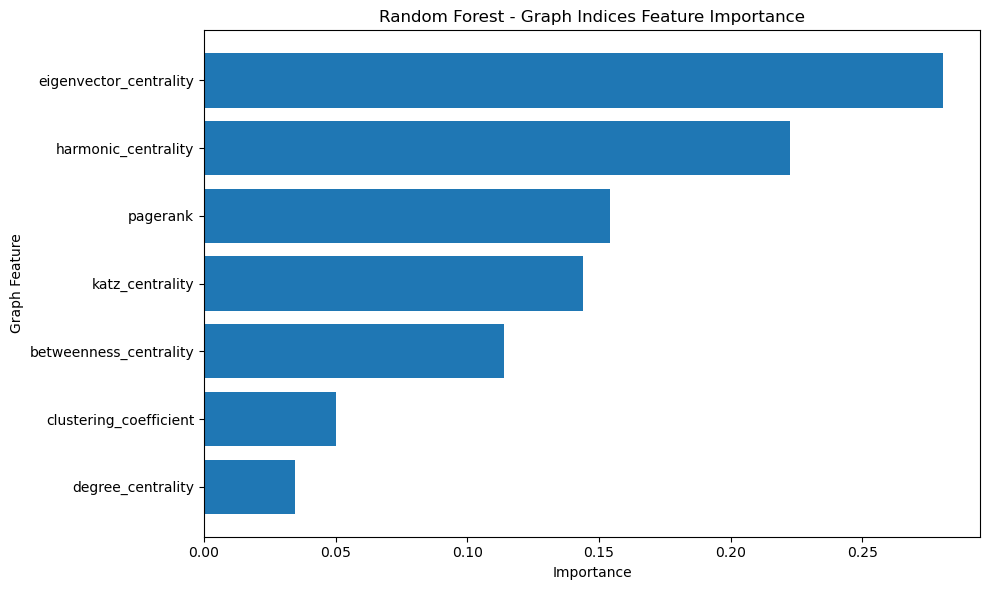


Orijinal + Graf İndeksleri Modelinde Graf İndekslerinin Önemi


,Feature,Importance
0,eigenvector_centrality,0.053893
1,harmonic_centrality,0.033005
2,pagerank,0.015907
3,katz_centrality,0.015702
4,betweenness_centrality,0.014635
5,degree_centrality,0.009578
6,clustering_coefficient,0.008990



Birleşik modelde toplam graf indeksi önemi: 0.151711
Birleşik modelde toplam orijinal feature önemi: 0.848289


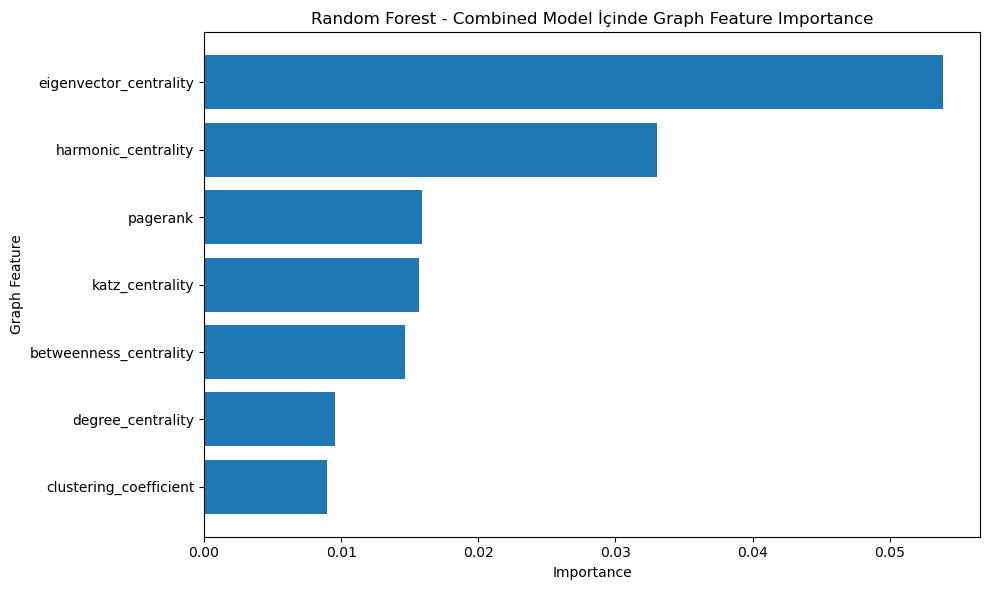


Orijinal + Graf İndeksleri Modelinde En Önemli İlk 20 Feature


,Feature,Importance
0,eigenvector_centrality,0.053893
1,harmonic_centrality,0.033005
2,496,0.028187
3,582,0.022797
4,1264,0.018127
5,pagerank,0.015907
6,775,0.015730
7,katz_centrality,0.015702
8,betweenness_centrality,0.014635
9,20,0.014010


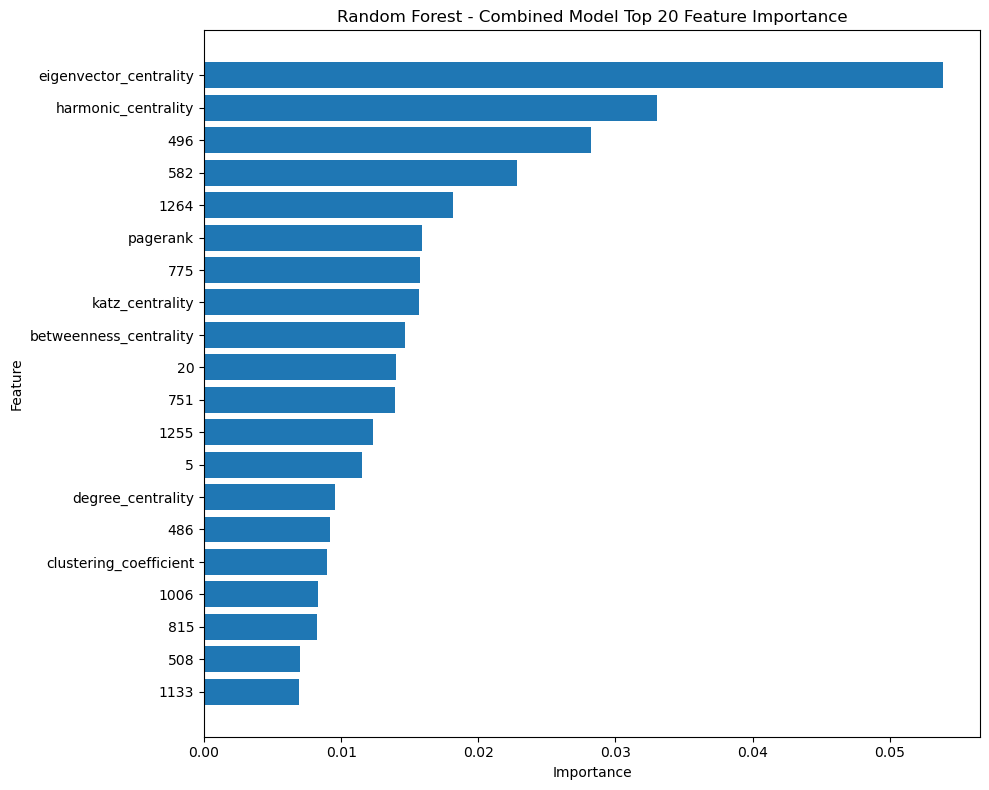

In [7]:
# ==================================================
# ADIM 7: Random Forest Feature Importance Analizi
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Sadece graf indeksleriyle eğitilen RF modelini al
# --------------------------------------------------

rf_graph_model = result_graph["model"]

graph_importance_df = pd.DataFrame({
    "Feature": X_graph_only.columns,
    "Importance": rf_graph_model.feature_importances_
})

graph_importance_df = graph_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("="*60)
print("Sadece Graf İndeksleri Modeli - Feature Importance")
print("="*60)

display(graph_importance_df)

# --------------------------------------------------
# 2. Graf indekslerinin önemini görselleştir
# --------------------------------------------------

plt.figure(figsize=(10, 6))
plt.barh(
    graph_importance_df["Feature"],
    graph_importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Graph Feature")
plt.title("Random Forest - Graph Indices Feature Importance")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3. Orijinal + graf indeksleri modelinde graf indekslerinin önemini al
# --------------------------------------------------

rf_combined_model = result_combined["model"]

combined_importance_df = pd.DataFrame({
    "Feature": X_combined.columns,
    "Importance": rf_combined_model.feature_importances_
})

# Sadece bizim eklediğimiz graf indekslerini filtreleyelim
combined_graph_importance_df = combined_importance_df[
    combined_importance_df["Feature"].isin(graph_feature_columns)
].copy()

combined_graph_importance_df = combined_graph_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("\n" + "="*60)
print("Orijinal + Graf İndeksleri Modelinde Graf İndekslerinin Önemi")
print("="*60)

display(combined_graph_importance_df)

# --------------------------------------------------
# 4. Birleşik modelde graf indekslerinin toplam katkısı
# --------------------------------------------------

total_graph_importance = combined_graph_importance_df["Importance"].sum()
total_original_importance = 1 - total_graph_importance

print("\nBirleşik modelde toplam graf indeksi önemi:", round(total_graph_importance, 6))
print("Birleşik modelde toplam orijinal feature önemi:", round(total_original_importance, 6))

# --------------------------------------------------
# 5. Birleşik modelde graf indekslerinin önem grafiği
# --------------------------------------------------

plt.figure(figsize=(10, 6))
plt.barh(
    combined_graph_importance_df["Feature"],
    combined_graph_importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Graph Feature")
plt.title("Random Forest - Combined Model İçinde Graph Feature Importance")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. En önemli ilk 20 özelliği de görelim
# --------------------------------------------------

top20_combined_importance_df = combined_importance_df.sort_values(
    by="Importance",
    ascending=False
).head(20).reset_index(drop=True)

print("\n" + "="*60)
print("Orijinal + Graf İndeksleri Modelinde En Önemli İlk 20 Feature")
print("="*60)

display(top20_combined_importance_df)

plt.figure(figsize=(10, 8))
plt.barh(
    top20_combined_importance_df["Feature"],
    top20_combined_importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Combined Model Top 20 Feature Importance")
plt.tight_layout()
plt.show()

In [8]:
# ==================================================
# ADIM 8: XGBoost ile Kontrollü Model Eğitimi
# ==================================================

!pip install xgboost

import time
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# --------------------------------------------------
# 1. XGBoost hızlı mod ayarı
# --------------------------------------------------

FAST_MODE = True

if FAST_MODE:
    xgb_params = {
        "n_estimators": 50,
        "max_depth": 3,
        "learning_rate": 0.08,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "tree_method": "hist",
        "eval_metric": "mlogloss",
        "objective": "multi:softprob",
        "num_class": len(label_encoder.classes_),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": 1
    }
else:
    xgb_params = {
        "n_estimators": 100,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "tree_method": "hist",
        "eval_metric": "mlogloss",
        "objective": "multi:softprob",
        "num_class": len(label_encoder.classes_),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": 1
    }

print("XGBoost parametreleri:")
print(xgb_params)

# --------------------------------------------------
# 2. XGBoost eğitim ve değerlendirme fonksiyonu
# --------------------------------------------------

def train_evaluate_xgboost(X, y_train, y_test, train_idx, test_idx, experiment_name):
    """
    Verilen feature set ile XGBoost modelini eğitir ve temel metrikleri döndürür.
    """
    
    print("\n" + "="*70)
    print(experiment_name)
    print("="*70)
    
    start_time = time.time()
    
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    
    model = XGBClassifier(**xgb_params)
    
    print("Model eğitimi başladı...")
    model.fit(X_train, y_train)
    print("Model eğitimi tamamlandı.")
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    
    elapsed_time = round(time.time() - start_time, 2)
    
    print("Süre:", elapsed_time, "saniye")
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))
    
    return {
        "experiment": experiment_name,
        "model": model,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "elapsed_time": elapsed_time,
        "y_pred": y_pred
    }

# --------------------------------------------------
# 3. Deney 1: Sadece orijinal Cora özellikleri
# --------------------------------------------------

xgb_result_original = train_evaluate_xgboost(
    X=X_original_only,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 1 - XGBoost / Sadece Orijinal Cora Özellikleri"
)

# --------------------------------------------------
# 4. Deney 2: Sadece graf indeksleri
# --------------------------------------------------

xgb_result_graph = train_evaluate_xgboost(
    X=X_graph_only,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 2 - XGBoost / Sadece Graf İndeksleri"
)

# --------------------------------------------------
# 5. Deney 3: Orijinal özellikler + graf indeksleri
# --------------------------------------------------

xgb_result_combined = train_evaluate_xgboost(
    X=X_combined,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 3 - XGBoost / Orijinal Özellikler + Graf İndeksleri"
)

# --------------------------------------------------
# 6. XGBoost sonuç tablosu
# --------------------------------------------------

xgb_results_df = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Feature_Set": "Original Cora Features",
        "Accuracy": xgb_result_original["accuracy"],
        "Macro_F1": xgb_result_original["macro_f1"],
        "Weighted_F1": xgb_result_original["weighted_f1"],
        "Time_sec": xgb_result_original["elapsed_time"]
    },
    {
        "Model": "XGBoost",
        "Feature_Set": "Graph Indices Only",
        "Accuracy": xgb_result_graph["accuracy"],
        "Macro_F1": xgb_result_graph["macro_f1"],
        "Weighted_F1": xgb_result_graph["weighted_f1"],
        "Time_sec": xgb_result_graph["elapsed_time"]
    },
    {
        "Model": "XGBoost",
        "Feature_Set": "Original + Graph Indices",
        "Accuracy": xgb_result_combined["accuracy"],
        "Macro_F1": xgb_result_combined["macro_f1"],
        "Weighted_F1": xgb_result_combined["weighted_f1"],
        "Time_sec": xgb_result_combined["elapsed_time"]
    }
])

print("\n" + "="*70)
print("XGBoost Karşılaştırma Tablosu")
print("="*70)

display(xgb_results_df)

XGBoost parametreleri:
{'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.08, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'eval_metric': 'mlogloss', 'objective': 'multi:softprob', 'num_class': 7, 'random_state': 42, 'n_jobs': -1, 'verbosity': 1}

Deney 1 - XGBoost / Sadece Orijinal Cora Özellikleri
Model eğitimi başladı...
Model eğitimi tamamlandı.
Süre: 1.13 saniye
Accuracy: 0.7122
Macro F1: 0.6889
Weighted F1: 0.7091

Classification Report:
                        precision    recall  f1-score   support

            Case_Based       0.94      0.55      0.69        60
    Genetic_Algorithms       0.93      0.80      0.86        84
       Neural_Networks       0.58      0.91      0.71       164
 Probabilistic_Methods       0.81      0.66      0.73        85
Reinforcement_Learning       0.81      0.60      0.69        43
         Rule_Learning       0.81      0.36      0.50        36
                Theory       0.71      0.59      0.64        70

            

,Model,Feature_Set,Accuracy,Macro_F1,Weighted_F1,Time_sec
0,XGBoost,Original Cora Features,0.712177,0.688927,0.709135,1.13
1,XGBoost,Graph Indices Only,0.507380,0.437834,0.473509,0.18
2,XGBoost,Original + Graph Indices,0.750923,0.729273,0.746079,1.57


XGBoost - Sadece Graf İndeksleri Modeli Feature Importance


,Feature,Importance
0,eigenvector_centrality,0.344763
1,harmonic_centrality,0.191091
2,katz_centrality,0.118134
3,betweenness_centrality,0.115749
4,degree_centrality,0.089673
5,pagerank,0.074351
6,clustering_coefficient,0.066241


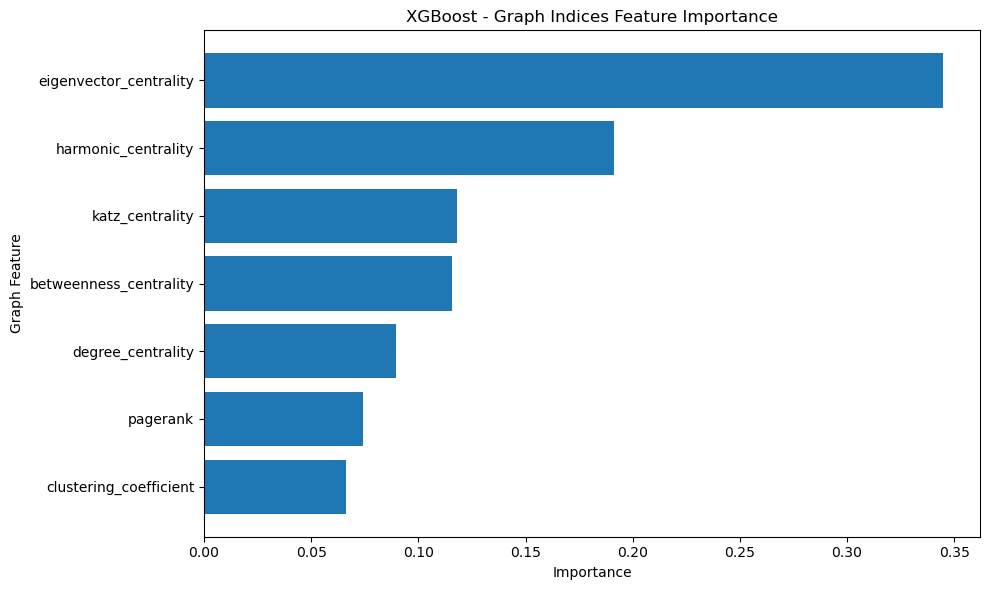


XGBoost - Orijinal + Graf İndeksleri Modelinde Graf İndekslerinin Önemi


,Feature,Importance
0,eigenvector_centrality,0.012607
1,harmonic_centrality,0.004138
2,katz_centrality,0.003249
3,betweenness_centrality,0.002573
4,pagerank,0.001171
5,degree_centrality,0.001094
6,clustering_coefficient,0.000853



XGBoost birleşik modelde toplam graf indeksi önemi: 0.025686
XGBoost birleşik modelde toplam orijinal feature önemi: 0.974314


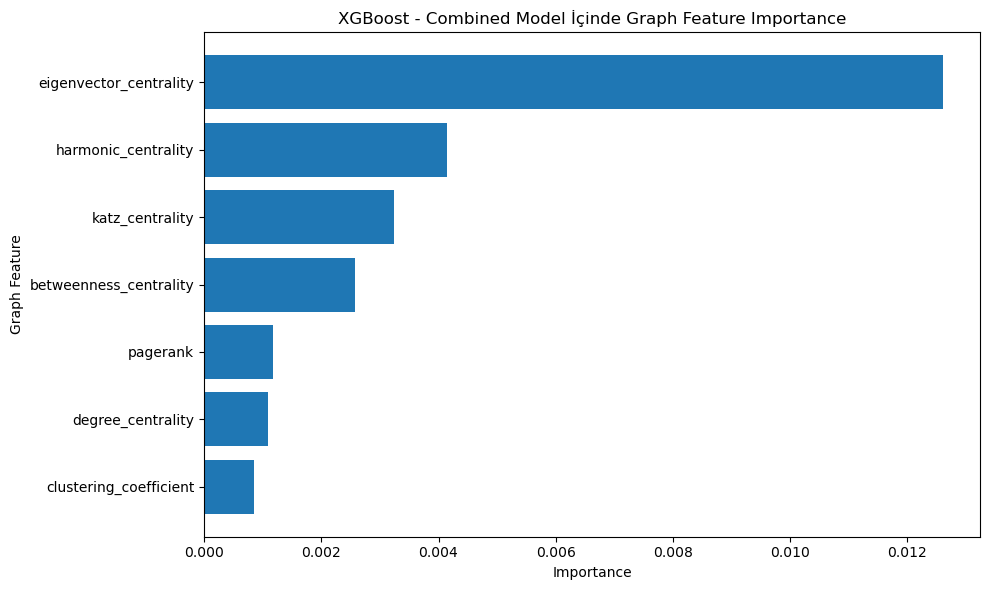


XGBoost - Orijinal + Graf İndeksleri Modelinde En Önemli İlk 20 Feature


,Feature,Importance
0,582,0.029743
1,775,0.028555
2,751,0.025404
3,496,0.024783
4,486,0.017105
5,1255,0.016179
6,1247,0.015290
7,822,0.013369
8,52,0.013307
9,eigenvector_centrality,0.012607


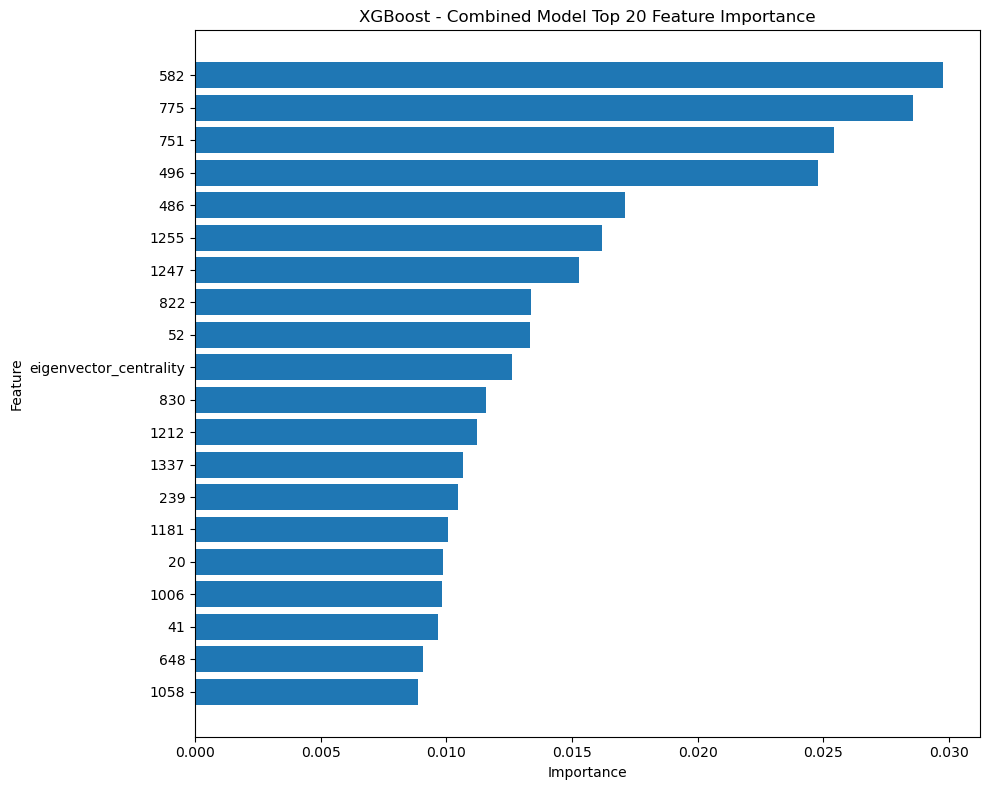

In [9]:
# ==================================================
# ADIM 9: XGBoost Feature Importance Analizi
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Sadece graf indeksleriyle eğitilen XGBoost modelini al
# --------------------------------------------------

xgb_graph_model = xgb_result_graph["model"]

xgb_graph_importance_df = pd.DataFrame({
    "Feature": X_graph_only.columns,
    "Importance": xgb_graph_model.feature_importances_
})

xgb_graph_importance_df = xgb_graph_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("="*70)
print("XGBoost - Sadece Graf İndeksleri Modeli Feature Importance")
print("="*70)

display(xgb_graph_importance_df)

# --------------------------------------------------
# 2. Sadece graf indeksleri modelinin importance grafiği
# --------------------------------------------------

plt.figure(figsize=(10, 6))
plt.barh(
    xgb_graph_importance_df["Feature"],
    xgb_graph_importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Graph Feature")
plt.title("XGBoost - Graph Indices Feature Importance")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3. Orijinal + graf indeksleri modelinde tüm feature importance
# --------------------------------------------------

xgb_combined_model = xgb_result_combined["model"]

xgb_combined_importance_df = pd.DataFrame({
    "Feature": X_combined.columns,
    "Importance": xgb_combined_model.feature_importances_
})

# --------------------------------------------------
# 4. Birleşik model içinde sadece graf indekslerini filtrele
# --------------------------------------------------

xgb_combined_graph_importance_df = xgb_combined_importance_df[
    xgb_combined_importance_df["Feature"].isin(graph_feature_columns)
].copy()

xgb_combined_graph_importance_df = xgb_combined_graph_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("\n" + "="*70)
print("XGBoost - Orijinal + Graf İndeksleri Modelinde Graf İndekslerinin Önemi")
print("="*70)

display(xgb_combined_graph_importance_df)

# --------------------------------------------------
# 5. Birleşik modelde graf indekslerinin toplam katkısı
# --------------------------------------------------

xgb_total_graph_importance = xgb_combined_graph_importance_df["Importance"].sum()
xgb_total_original_importance = 1 - xgb_total_graph_importance

print("\nXGBoost birleşik modelde toplam graf indeksi önemi:", round(xgb_total_graph_importance, 6))
print("XGBoost birleşik modelde toplam orijinal feature önemi:", round(xgb_total_original_importance, 6))

# --------------------------------------------------
# 6. Birleşik modelde graf indeksleri importance grafiği
# --------------------------------------------------

plt.figure(figsize=(10, 6))
plt.barh(
    xgb_combined_graph_importance_df["Feature"],
    xgb_combined_graph_importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Graph Feature")
plt.title("XGBoost - Combined Model İçinde Graph Feature Importance")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. Birleşik modelde en önemli ilk 20 feature
# --------------------------------------------------

xgb_top20_combined_importance_df = xgb_combined_importance_df.sort_values(
    by="Importance",
    ascending=False
).head(20).reset_index(drop=True)

print("\n" + "="*70)
print("XGBoost - Orijinal + Graf İndeksleri Modelinde En Önemli İlk 20 Feature")
print("="*70)

display(xgb_top20_combined_importance_df)

plt.figure(figsize=(10, 8))
plt.barh(
    xgb_top20_combined_importance_df["Feature"],
    xgb_top20_combined_importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost - Combined Model Top 20 Feature Importance")
plt.tight_layout()
plt.show()

In [10]:
# ==================================================
# ADIM 10 - GÜVENLİ SVM SÜRÜMÜ
# ==================================================

import time
import pandas as pd
import numpy as np

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

# --------------------------------------------------
# 1. Güvenli ve hızlı SVM fonksiyonu
# --------------------------------------------------

def train_evaluate_fast_svm(X, y_train, y_test, train_idx, test_idx, experiment_name):
    print("\n" + "="*70)
    print(experiment_name)
    print("="*70)
    
    start_time = time.time()
    
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    
    model = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("svm", LinearSVC(
            C=0.5,
            dual=False,
            random_state=42,
            max_iter=2000,
            tol=1e-3
        ))
    ])
    
    print("Model eğitimi başladı...")
    model.fit(X_train, y_train)
    print("Model eğitimi tamamlandı.")
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    
    elapsed_time = round(time.time() - start_time, 2)
    
    print("Süre:", elapsed_time, "saniye")
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))
    
    return {
        "experiment": experiment_name,
        "model": model,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "elapsed_time": elapsed_time,
        "y_pred": y_pred
    }

# --------------------------------------------------
# 2. Deney 1: Sadece orijinal Cora özellikleri
# --------------------------------------------------

svm_result_original = train_evaluate_fast_svm(
    X=X_original_only,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 1 - Linear SVM / Sadece Orijinal Cora Özellikleri"
)

# --------------------------------------------------
# 3. Deney 2: Sadece graf indeksleri
# --------------------------------------------------

svm_result_graph = train_evaluate_fast_svm(
    X=X_graph_only,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 2 - Linear SVM / Sadece Graf İndeksleri"
)

# --------------------------------------------------
# 4. Deney 3: Orijinal özellikler + graf indeksleri
# --------------------------------------------------

svm_result_combined = train_evaluate_fast_svm(
    X=X_combined,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 3 - Linear SVM / Orijinal Özellikler + Graf İndeksleri"
)

# --------------------------------------------------
# 5. SVM sonuç tablosu
# --------------------------------------------------

svm_results_df = pd.DataFrame([
    {
        "Model": "Linear SVM",
        "Feature_Set": "Original Cora Features",
        "Accuracy": svm_result_original["accuracy"],
        "Macro_F1": svm_result_original["macro_f1"],
        "Weighted_F1": svm_result_original["weighted_f1"],
        "Time_sec": svm_result_original["elapsed_time"]
    },
    {
        "Model": "Linear SVM",
        "Feature_Set": "Graph Indices Only",
        "Accuracy": svm_result_graph["accuracy"],
        "Macro_F1": svm_result_graph["macro_f1"],
        "Weighted_F1": svm_result_graph["weighted_f1"],
        "Time_sec": svm_result_graph["elapsed_time"]
    },
    {
        "Model": "Linear SVM",
        "Feature_Set": "Original + Graph Indices",
        "Accuracy": svm_result_combined["accuracy"],
        "Macro_F1": svm_result_combined["macro_f1"],
        "Weighted_F1": svm_result_combined["weighted_f1"],
        "Time_sec": svm_result_combined["elapsed_time"]
    }
])

print("\n" + "="*70)
print("Linear SVM Karşılaştırma Tablosu")
print("="*70)

display(svm_results_df)


Deney 1 - Linear SVM / Sadece Orijinal Cora Özellikleri
Model eğitimi başladı...
Model eğitimi tamamlandı.
Süre: 1.43 saniye
Accuracy: 0.69
Macro F1: 0.6624
Weighted F1: 0.6873

Classification Report:
                        precision    recall  f1-score   support

            Case_Based       0.71      0.62      0.66        60
    Genetic_Algorithms       0.80      0.83      0.82        84
       Neural_Networks       0.68      0.72      0.70       164
 Probabilistic_Methods       0.74      0.72      0.73        85
Reinforcement_Learning       0.65      0.70      0.67        43
         Rule_Learning       0.62      0.36      0.46        36
                Theory       0.56      0.64      0.60        70

              accuracy                           0.69       542
             macro avg       0.68      0.66      0.66       542
          weighted avg       0.69      0.69      0.69       542


Deney 2 - Linear SVM / Sadece Graf İndeksleri
Model eğitimi başladı...
Model eğitimi tamam

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model eğitimi tamamlandı.
Süre: 0.33 saniye
Accuracy: 0.7177
Macro F1: 0.6977
Weighted F1: 0.7153

Classification Report:
                        precision    recall  f1-score   support

            Case_Based       0.75      0.70      0.72        60
    Genetic_Algorithms       0.80      0.83      0.81        84
       Neural_Networks       0.71      0.74      0.72       164
 Probabilistic_Methods       0.75      0.78      0.76        85
Reinforcement_Learning       0.70      0.72      0.71        43
         Rule_Learning       0.70      0.44      0.54        36
                Theory       0.60      0.61      0.61        70

              accuracy                           0.72       542
             macro avg       0.71      0.69      0.70       542
          weighted avg       0.72      0.72      0.72       542


Linear SVM Karşılaştırma Tablosu


,Model,Feature_Set,Accuracy,Macro_F1,Weighted_F1,Time_sec
0,Linear SVM,Original Cora Features,0.690037,0.662370,0.687253,1.43
1,Linear SVM,Graph Indices Only,0.400369,0.237615,0.309447,0.02
2,Linear SVM,Original + Graph Indices,0.717712,0.697734,0.715334,0.33


In [11]:
# ==================================================
# ADIM 11: MLP ile Model Eğitimi
# ==================================================

import time
import pandas as pd
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

# --------------------------------------------------
# 1. MLP eğitim ve değerlendirme fonksiyonu
# --------------------------------------------------

def train_evaluate_mlp(X, y_train, y_test, train_idx, test_idx, experiment_name):
    """
    Verilen feature set ile MLP modelini eğitir ve temel metrikleri döndürür.
    """
    
    print("\n" + "="*70)
    print(experiment_name)
    print("="*70)
    
    start_time = time.time()
    
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.001,
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=15,
            random_state=42,
            verbose=False
        ))
    ])
    
    print("Model eğitimi başladı...")
    model.fit(X_train, y_train)
    print("Model eğitimi tamamlandı.")
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    
    elapsed_time = round(time.time() - start_time, 2)
    
    print("Süre:", elapsed_time, "saniye")
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))
    
    return {
        "experiment": experiment_name,
        "model": model,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "elapsed_time": elapsed_time,
        "y_pred": y_pred
    }

# --------------------------------------------------
# 2. Deney 1: Sadece orijinal Cora özellikleri
# --------------------------------------------------

mlp_result_original = train_evaluate_mlp(
    X=X_original_only,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 1 - MLP / Sadece Orijinal Cora Özellikleri"
)

# --------------------------------------------------
# 3. Deney 2: Sadece graf indeksleri
# --------------------------------------------------

mlp_result_graph = train_evaluate_mlp(
    X=X_graph_only,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 2 - MLP / Sadece Graf İndeksleri"
)

# --------------------------------------------------
# 4. Deney 3: Orijinal özellikler + graf indeksleri
# --------------------------------------------------

mlp_result_combined = train_evaluate_mlp(
    X=X_combined,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    experiment_name="Deney 3 - MLP / Orijinal Özellikler + Graf İndeksleri"
)

# --------------------------------------------------
# 5. MLP sonuç tablosu
# --------------------------------------------------

mlp_results_df = pd.DataFrame([
    {
        "Model": "MLP",
        "Feature_Set": "Original Cora Features",
        "Accuracy": mlp_result_original["accuracy"],
        "Macro_F1": mlp_result_original["macro_f1"],
        "Weighted_F1": mlp_result_original["weighted_f1"],
        "Time_sec": mlp_result_original["elapsed_time"]
    },
    {
        "Model": "MLP",
        "Feature_Set": "Graph Indices Only",
        "Accuracy": mlp_result_graph["accuracy"],
        "Macro_F1": mlp_result_graph["macro_f1"],
        "Weighted_F1": mlp_result_graph["weighted_f1"],
        "Time_sec": mlp_result_graph["elapsed_time"]
    },
    {
        "Model": "MLP",
        "Feature_Set": "Original + Graph Indices",
        "Accuracy": mlp_result_combined["accuracy"],
        "Macro_F1": mlp_result_combined["macro_f1"],
        "Weighted_F1": mlp_result_combined["weighted_f1"],
        "Time_sec": mlp_result_combined["elapsed_time"]
    }
])

print("\n" + "="*70)
print("MLP Karşılaştırma Tablosu")
print("="*70)

display(mlp_results_df)


Deney 1 - MLP / Sadece Orijinal Cora Özellikleri
Model eğitimi başladı...
Model eğitimi tamamlandı.
Süre: 1.93 saniye
Accuracy: 0.6624
Macro F1: 0.6385
Weighted F1: 0.6602

Classification Report:
                        precision    recall  f1-score   support

            Case_Based       0.72      0.72      0.72        60
    Genetic_Algorithms       0.65      0.68      0.66        84
       Neural_Networks       0.69      0.72      0.71       164
 Probabilistic_Methods       0.67      0.73      0.70        85
Reinforcement_Learning       0.65      0.51      0.57        43
         Rule_Learning       0.65      0.47      0.55        36
                Theory       0.56      0.57      0.56        70

              accuracy                           0.66       542
             macro avg       0.66      0.63      0.64       542
          weighted avg       0.66      0.66      0.66       542


Deney 2 - MLP / Sadece Graf İndeksleri
Model eğitimi başladı...
Model eğitimi tamamlandı.
Süre:

,Model,Feature_Set,Accuracy,Macro_F1,Weighted_F1,Time_sec
0,MLP,Original Cora Features,0.662362,0.638544,0.660245,1.93
1,MLP,Graph Indices Only,0.453875,0.344386,0.402300,0.59
2,MLP,Original + Graph Indices,0.695572,0.677325,0.695736,2.79


Tüm Modellerin Genel Karşılaştırma Tablosu


/var/folders/3_/c03tl61n1hn4q28mzc4ltgkc0000gn/T/ipykernel_75112/1557509421.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results_df = pd.concat(


,Model,Feature_Set,Accuracy,Macro_F1,Weighted_F1,Time_sec
0,Random Forest,Original Cora Features,0.7731,0.7646,0.7725,NaN
1,Random Forest,Graph Indices Only,0.5627,0.5369,0.5565,NaN
2,Random Forest,Original + Graph Indices,0.7860,0.7709,0.7832,NaN
3,XGBoost,Original Cora Features,0.7122,0.6889,0.7091,1.13
4,XGBoost,Graph Indices Only,0.5074,0.4378,0.4735,0.18
5,XGBoost,Original + Graph Indices,0.7509,0.7293,0.7461,1.57
6,Linear SVM,Original Cora Features,0.6900,0.6624,0.6873,1.43
7,Linear SVM,Graph Indices Only,0.4004,0.2376,0.3094,0.02
8,Linear SVM,Original + Graph Indices,0.7177,0.6977,0.7153,0.33
9,MLP,Original Cora Features,0.6624,0.6385,0.6602,1.93



Graf İndeksleri Eklenince Accuracy Artışı


,Model,Original_Accuracy,Graph_Only_Accuracy,Combined_Accuracy,Accuracy_Improvement
0,Random Forest,0.7731,0.5627,0.7860,0.0129
1,XGBoost,0.7122,0.5074,0.7509,0.0387
2,Linear SVM,0.6900,0.4004,0.7177,0.0277
3,MLP,0.6624,0.4539,0.6956,0.0332


<Figure size 1000x600 with 0 Axes>

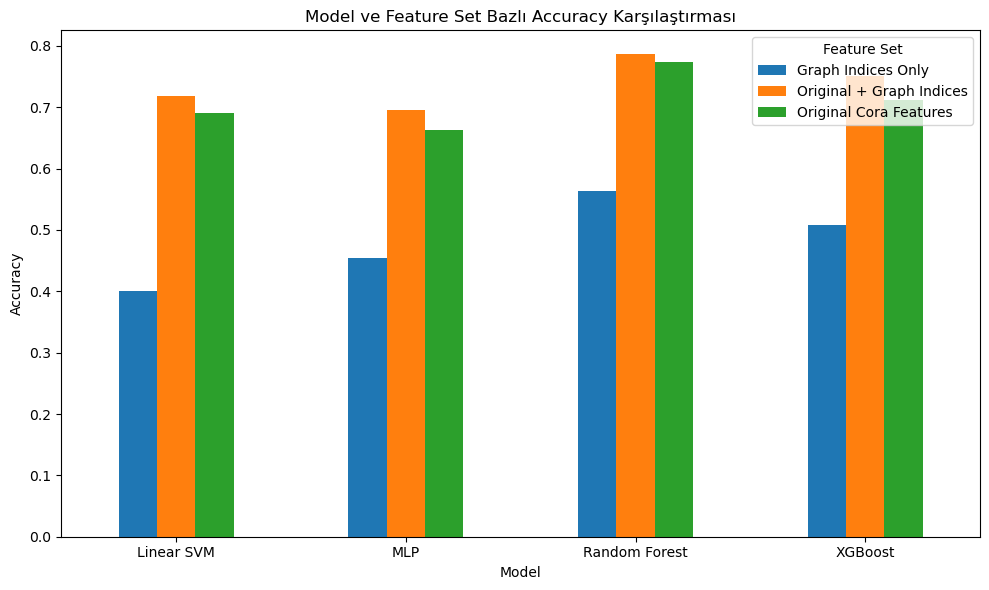

<Figure size 1000x600 with 0 Axes>

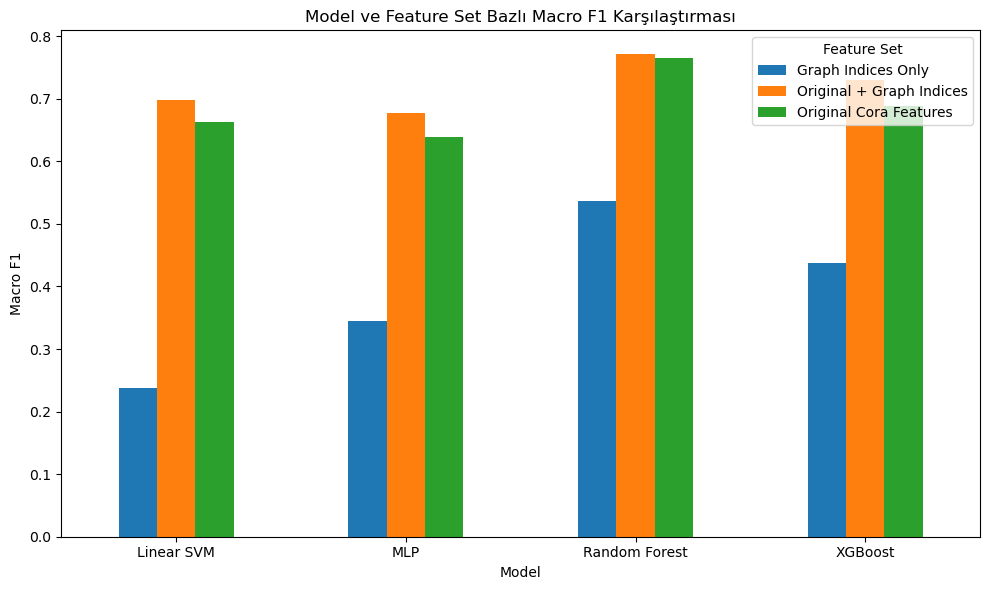

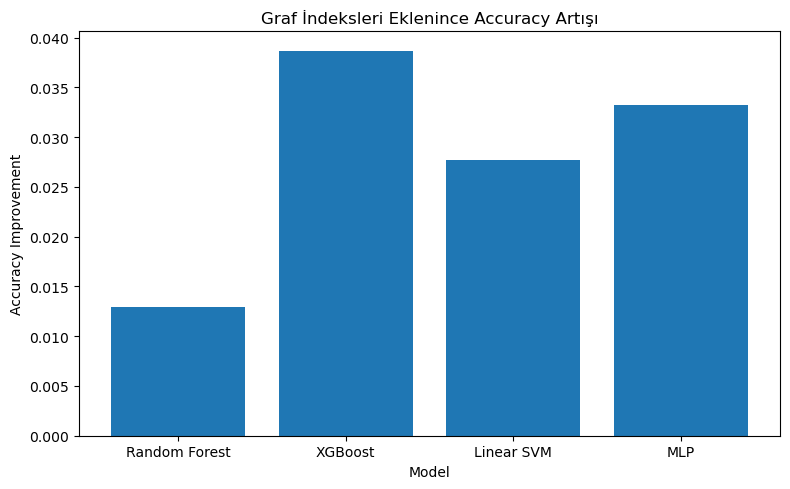


Accuracy Değerine Göre En İyi Sonuçlar


,Model,Feature_Set,Accuracy,Macro_F1,Weighted_F1,Time_sec
0,Random Forest,Original + Graph Indices,0.7860,0.7709,0.7832,NaN
1,Random Forest,Original Cora Features,0.7731,0.7646,0.7725,NaN
2,XGBoost,Original + Graph Indices,0.7509,0.7293,0.7461,1.57
3,Linear SVM,Original + Graph Indices,0.7177,0.6977,0.7153,0.33
4,XGBoost,Original Cora Features,0.7122,0.6889,0.7091,1.13
5,MLP,Original + Graph Indices,0.6956,0.6773,0.6957,2.79
6,Linear SVM,Original Cora Features,0.6900,0.6624,0.6873,1.43
7,MLP,Original Cora Features,0.6624,0.6385,0.6602,1.93
8,Random Forest,Graph Indices Only,0.5627,0.5369,0.5565,NaN
9,XGBoost,Graph Indices Only,0.5074,0.4378,0.4735,0.18


In [12]:
# ==================================================
# ADIM 12: Tüm Model Sonuçlarını Birleştirme
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Sonuç tablolarını aynı formata getirme
# --------------------------------------------------

# Random Forest tablosunda Time_sec yoktu, ekleyelim
rf_results_df_copy = rf_results_df.copy()
rf_results_df_copy["Time_sec"] = None

xgb_results_df_copy = xgb_results_df.copy()
svm_results_df_copy = svm_results_df.copy()
mlp_results_df_copy = mlp_results_df.copy()

# Kolon sırasını standartlaştıralım
common_columns = [
    "Model",
    "Feature_Set",
    "Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Time_sec"
]

rf_results_df_copy = rf_results_df_copy[common_columns]
xgb_results_df_copy = xgb_results_df_copy[common_columns]
svm_results_df_copy = svm_results_df_copy[common_columns]
mlp_results_df_copy = mlp_results_df_copy[common_columns]

# --------------------------------------------------
# 2. Tüm sonuçları tek tabloda birleştirme
# --------------------------------------------------

all_results_df = pd.concat(
    [
        rf_results_df_copy,
        xgb_results_df_copy,
        svm_results_df_copy,
        mlp_results_df_copy
    ],
    axis=0,
    ignore_index=True
)

# Sayısal değerleri yuvarlayalım
all_results_df["Accuracy"] = all_results_df["Accuracy"].round(4)
all_results_df["Macro_F1"] = all_results_df["Macro_F1"].round(4)
all_results_df["Weighted_F1"] = all_results_df["Weighted_F1"].round(4)

print("="*80)
print("Tüm Modellerin Genel Karşılaştırma Tablosu")
print("="*80)

display(all_results_df)

# --------------------------------------------------
# 3. Her model için Original ve Combined farkını hesaplama
# --------------------------------------------------

improvement_rows = []

for model_name in all_results_df["Model"].unique():
    model_df = all_results_df[all_results_df["Model"] == model_name]
    
    original_acc = model_df[
        model_df["Feature_Set"] == "Original Cora Features"
    ]["Accuracy"].values[0]
    
    combined_acc = model_df[
        model_df["Feature_Set"] == "Original + Graph Indices"
    ]["Accuracy"].values[0]
    
    graph_only_acc = model_df[
        model_df["Feature_Set"] == "Graph Indices Only"
    ]["Accuracy"].values[0]
    
    improvement_rows.append({
        "Model": model_name,
        "Original_Accuracy": original_acc,
        "Graph_Only_Accuracy": graph_only_acc,
        "Combined_Accuracy": combined_acc,
        "Accuracy_Improvement": round(combined_acc - original_acc, 4)
    })

improvement_df = pd.DataFrame(improvement_rows)

print("\n" + "="*80)
print("Graf İndeksleri Eklenince Accuracy Artışı")
print("="*80)

display(improvement_df)

# --------------------------------------------------
# 4. Accuracy karşılaştırma grafiği
# --------------------------------------------------

pivot_accuracy = all_results_df.pivot(
    index="Model",
    columns="Feature_Set",
    values="Accuracy"
)

plt.figure(figsize=(10, 6))
pivot_accuracy.plot(kind="bar", figsize=(10, 6))
plt.title("Model ve Feature Set Bazlı Accuracy Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.legend(title="Feature Set")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5. Macro F1 karşılaştırma grafiği
# --------------------------------------------------

pivot_macro_f1 = all_results_df.pivot(
    index="Model",
    columns="Feature_Set",
    values="Macro_F1"
)

plt.figure(figsize=(10, 6))
pivot_macro_f1.plot(kind="bar", figsize=(10, 6))
plt.title("Model ve Feature Set Bazlı Macro F1 Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=0)
plt.legend(title="Feature Set")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. Accuracy improvement grafiği
# --------------------------------------------------

plt.figure(figsize=(8, 5))
plt.bar(
    improvement_df["Model"],
    improvement_df["Accuracy_Improvement"]
)
plt.title("Graf İndeksleri Eklenince Accuracy Artışı")
plt.xlabel("Model")
plt.ylabel("Accuracy Improvement")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. En iyi sonuçları sıralama
# --------------------------------------------------

best_results_df = all_results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n" + "="*80)
print("Accuracy Değerine Göre En İyi Sonuçlar")
print("="*80)

display(best_results_df)

Sonuç klasörü: results
Kaydedildi: results/all_model_results.csv
Kaydedildi: results/accuracy_improvement.csv


<Figure size 1100x600 with 0 Axes>

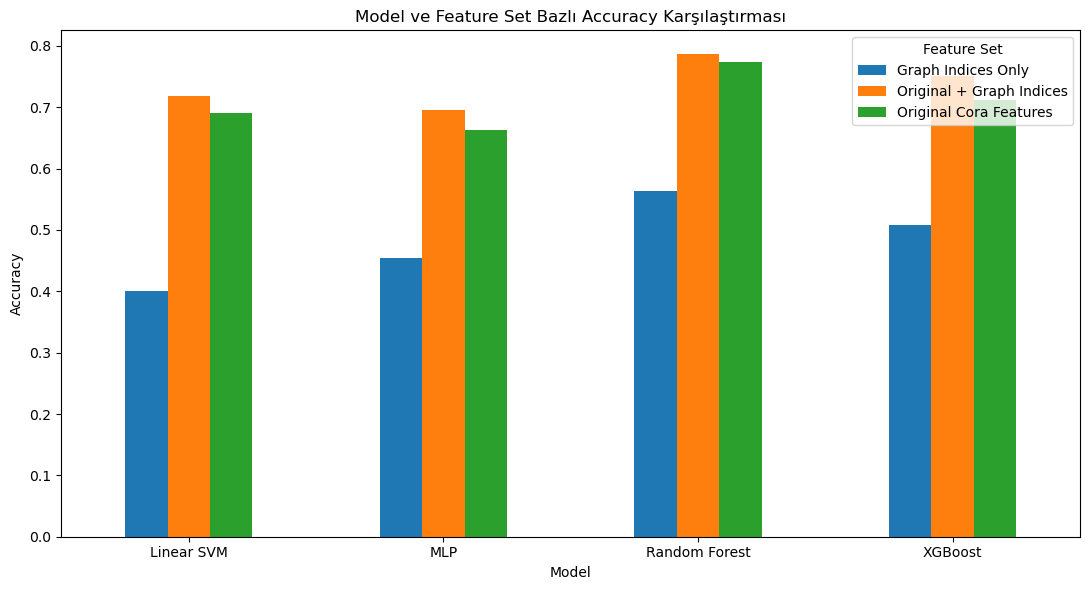

Kaydedildi: results/model_accuracy_comparison.png


<Figure size 1100x600 with 0 Axes>

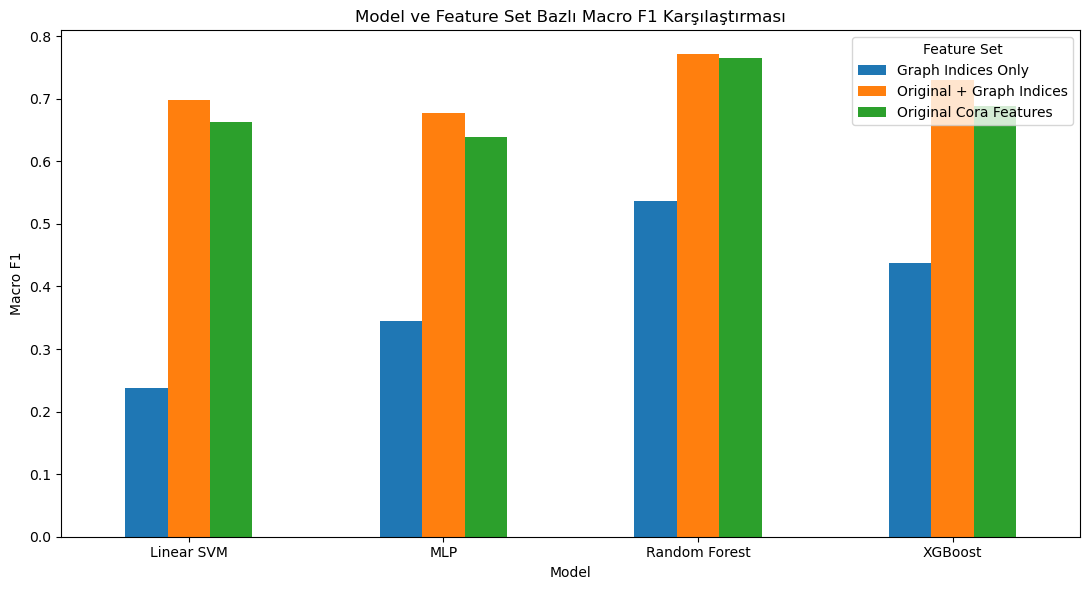

Kaydedildi: results/model_macro_f1_comparison.png


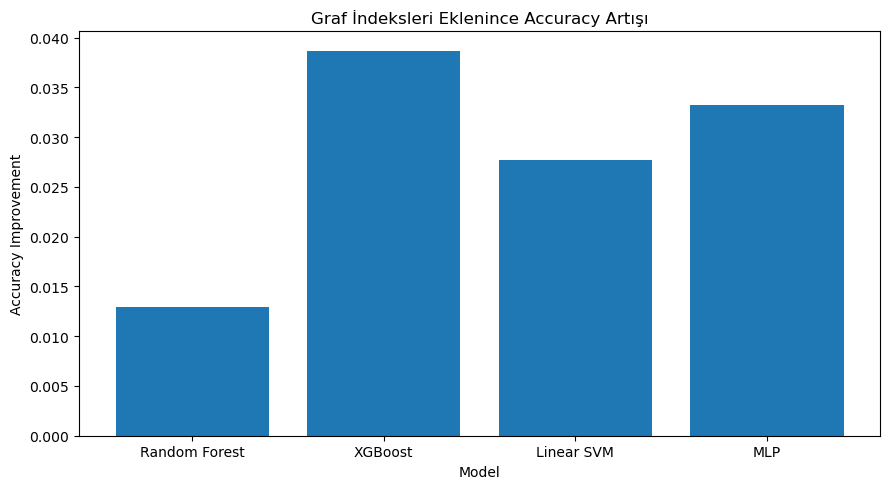

Kaydedildi: results/accuracy_improvement.png


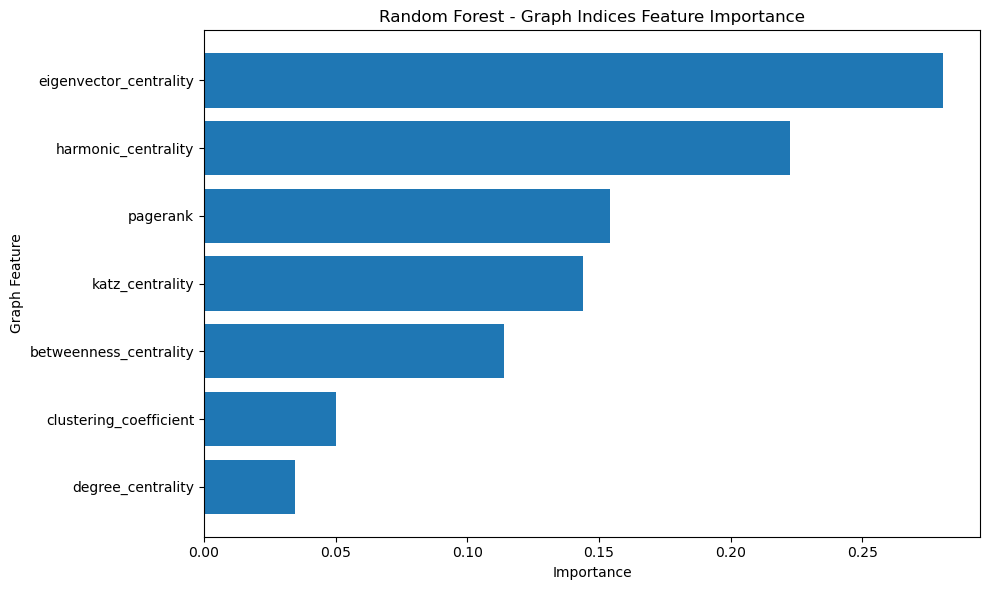

Kaydedildi: results/rf_graph_importance.csv
Kaydedildi: results/rf_graph_importance.png


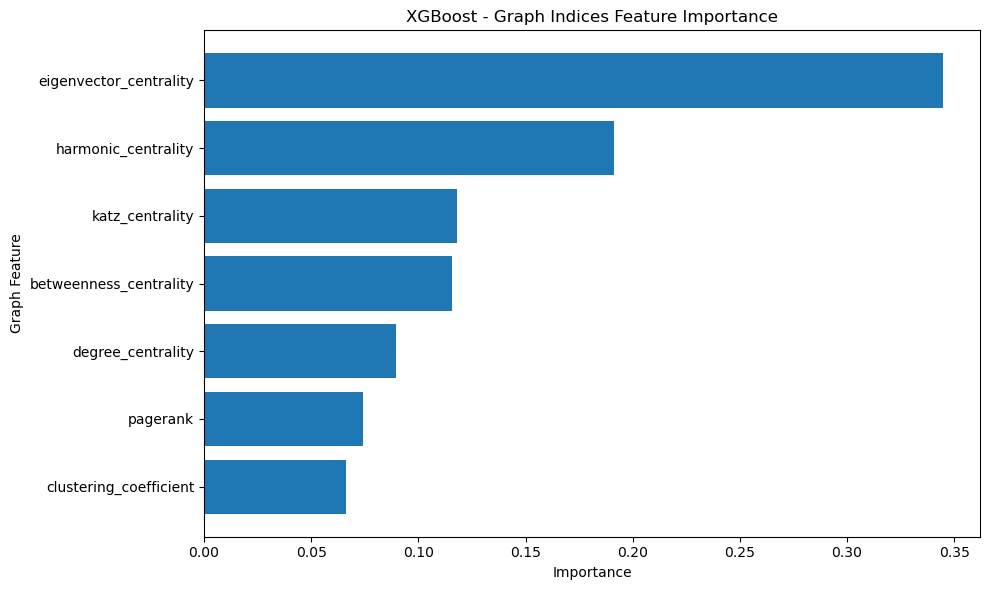

Kaydedildi: results/xgb_graph_importance.csv
Kaydedildi: results/xgb_graph_importance.png

Results klasöründeki dosyalar:
- accuracy_improvement.png
- model_macro_f1_comparison.png
- rf_graph_importance.png
- model_accuracy_comparison.png
- xgb_graph_importance.png
- xgb_graph_importance.csv
- all_model_results.csv
- accuracy_improvement.csv
- rf_graph_importance.csv


In [13]:
# ==================================================
# ADIM 13: Sonuç Tablolarını ve Grafikleri Kaydetme
# ==================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Sonuç klasörü oluşturma
# --------------------------------------------------

results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

print("Sonuç klasörü:", results_dir)

# --------------------------------------------------
# 2. Genel sonuç tablolarını CSV olarak kaydetme
# --------------------------------------------------

all_results_path = os.path.join(results_dir, "all_model_results.csv")
improvement_path = os.path.join(results_dir, "accuracy_improvement.csv")

all_results_df.to_csv(all_results_path, index=False, encoding="utf-8-sig")
improvement_df.to_csv(improvement_path, index=False, encoding="utf-8-sig")

print("Kaydedildi:", all_results_path)
print("Kaydedildi:", improvement_path)

# --------------------------------------------------
# 3. Accuracy karşılaştırma grafiğini kaydetme
# --------------------------------------------------

pivot_accuracy = all_results_df.pivot(
    index="Model",
    columns="Feature_Set",
    values="Accuracy"
)

plt.figure(figsize=(11, 6))
pivot_accuracy.plot(kind="bar", figsize=(11, 6))
plt.title("Model ve Feature Set Bazlı Accuracy Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.legend(title="Feature Set")
plt.tight_layout()

accuracy_fig_path = os.path.join(results_dir, "model_accuracy_comparison.png")
plt.savefig(accuracy_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", accuracy_fig_path)

# --------------------------------------------------
# 4. Macro F1 karşılaştırma grafiğini kaydetme
# --------------------------------------------------

pivot_macro_f1 = all_results_df.pivot(
    index="Model",
    columns="Feature_Set",
    values="Macro_F1"
)

plt.figure(figsize=(11, 6))
pivot_macro_f1.plot(kind="bar", figsize=(11, 6))
plt.title("Model ve Feature Set Bazlı Macro F1 Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=0)
plt.legend(title="Feature Set")
plt.tight_layout()

macro_f1_fig_path = os.path.join(results_dir, "model_macro_f1_comparison.png")
plt.savefig(macro_f1_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", macro_f1_fig_path)

# --------------------------------------------------
# 5. Accuracy improvement grafiğini kaydetme
# --------------------------------------------------

plt.figure(figsize=(9, 5))
plt.bar(
    improvement_df["Model"],
    improvement_df["Accuracy_Improvement"]
)
plt.title("Graf İndeksleri Eklenince Accuracy Artışı")
plt.xlabel("Model")
plt.ylabel("Accuracy Improvement")
plt.tight_layout()

improvement_fig_path = os.path.join(results_dir, "accuracy_improvement.png")
plt.savefig(improvement_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", improvement_fig_path)

# --------------------------------------------------
# 6. Random Forest graph feature importance kaydetme
# --------------------------------------------------

rf_graph_importance_csv_path = os.path.join(results_dir, "rf_graph_importance.csv")
graph_importance_df.to_csv(
    rf_graph_importance_csv_path,
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(10, 6))
plt.barh(
    graph_importance_df["Feature"],
    graph_importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Graph Feature")
plt.title("Random Forest - Graph Indices Feature Importance")
plt.tight_layout()

rf_graph_importance_fig_path = os.path.join(results_dir, "rf_graph_importance.png")
plt.savefig(rf_graph_importance_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", rf_graph_importance_csv_path)
print("Kaydedildi:", rf_graph_importance_fig_path)

# --------------------------------------------------
# 7. XGBoost graph feature importance kaydetme
# --------------------------------------------------

xgb_graph_importance_csv_path = os.path.join(results_dir, "xgb_graph_importance.csv")
xgb_graph_importance_df.to_csv(
    xgb_graph_importance_csv_path,
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(10, 6))
plt.barh(
    xgb_graph_importance_df["Feature"],
    xgb_graph_importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Graph Feature")
plt.title("XGBoost - Graph Indices Feature Importance")
plt.tight_layout()

xgb_graph_importance_fig_path = os.path.join(results_dir, "xgb_graph_importance.png")
plt.savefig(xgb_graph_importance_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", xgb_graph_importance_csv_path)
print("Kaydedildi:", xgb_graph_importance_fig_path)

# --------------------------------------------------
# 8. Kayıt kontrolü
# --------------------------------------------------

print("\nResults klasöründeki dosyalar:")
for file_name in os.listdir(results_dir):
    print("-", file_name)

Confusion Matrix - Random Forest - Original + Graph Indices


,Case_Based,Genetic_Algorithms,Neural_Networks,Probabilistic_Methods,Reinforcement_Learning,Rule_Learning,Theory
Case_Based,42,2,9,1,1,0,5
Genetic_Algorithms,0,75,8,0,0,0,1
Neural_Networks,1,6,142,7,2,0,6
Probabilistic_Methods,0,0,13,69,1,0,2
Reinforcement_Learning,0,3,5,0,35,0,0
Rule_Learning,3,0,8,0,0,17,8
Theory,3,1,14,3,2,1,46


<Figure size 1000x800 with 0 Axes>

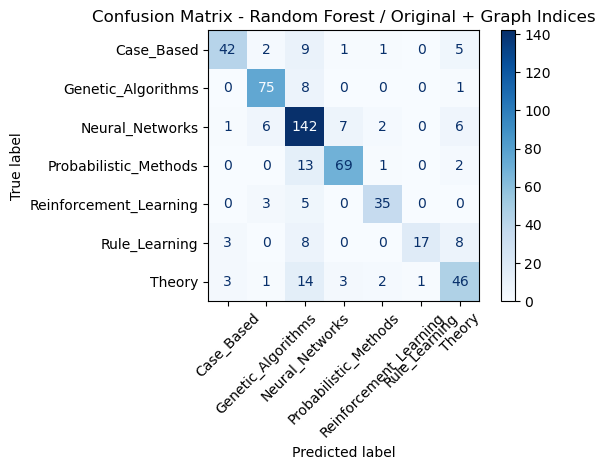


Normalize Edilmiş Confusion Matrix


,Case_Based,Genetic_Algorithms,Neural_Networks,Probabilistic_Methods,Reinforcement_Learning,Rule_Learning,Theory
Case_Based,0.700,0.033,0.150,0.017,0.017,0.000,0.083
Genetic_Algorithms,0.000,0.893,0.095,0.000,0.000,0.000,0.012
Neural_Networks,0.006,0.037,0.866,0.043,0.012,0.000,0.037
Probabilistic_Methods,0.000,0.000,0.153,0.812,0.012,0.000,0.024
Reinforcement_Learning,0.000,0.070,0.116,0.000,0.814,0.000,0.000
Rule_Learning,0.083,0.000,0.222,0.000,0.000,0.472,0.222
Theory,0.043,0.014,0.200,0.043,0.029,0.014,0.657


<Figure size 1000x800 with 0 Axes>

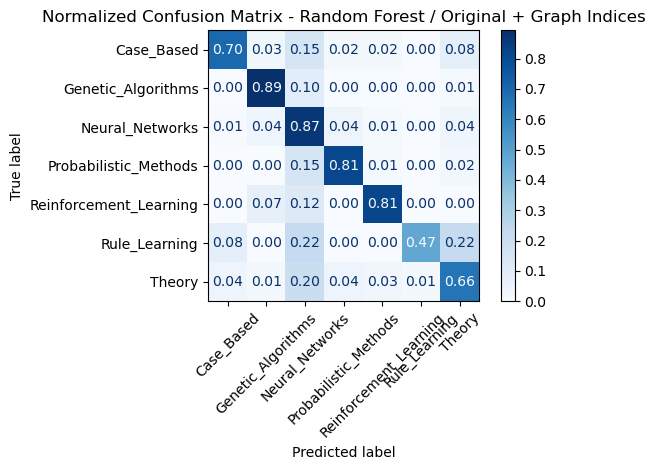


Classification Report - Tablo


,precision,recall,f1-score,support
Case_Based,0.8571,0.7000,0.7706,60.000
Genetic_Algorithms,0.8621,0.8929,0.8772,84.000
Neural_Networks,0.7136,0.8659,0.7824,164.000
Probabilistic_Methods,0.8625,0.8118,0.8364,85.000
Reinforcement_Learning,0.8537,0.8140,0.8333,43.000
Rule_Learning,0.9444,0.4722,0.6296,36.000
Theory,0.6765,0.6571,0.6667,70.000
accuracy,0.7860,0.7860,0.7860,0.786
macro avg,0.8243,0.7448,0.7709,542.000
weighted avg,0.7975,0.7860,0.7832,542.000



En Çok Karıştırılan Sınıf Çiftleri


,True_Label,Predicted_Label,Count
0,Theory,Neural_Networks,14
1,Probabilistic_Methods,Neural_Networks,13
2,Case_Based,Neural_Networks,9
3,Rule_Learning,Theory,8
4,Rule_Learning,Neural_Networks,8
5,Genetic_Algorithms,Neural_Networks,8
6,Neural_Networks,Probabilistic_Methods,7
7,Neural_Networks,Genetic_Algorithms,6
8,Neural_Networks,Theory,6
9,Case_Based,Theory,5



Kaydedilen dosyalar:
- results/rf_combined_confusion_matrix.csv
- results/rf_combined_confusion_matrix_normalized.csv
- results/rf_combined_classification_report.csv
- results/rf_combined_confusion_pairs.csv


In [14]:
# ==================================================
# ADIM 15: En İyi Model İçin Confusion Matrix Analizi
# ==================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# --------------------------------------------------
# 1. En iyi model: Random Forest + Original + Graph Indices
# --------------------------------------------------

best_model = result_combined["model"]   # Random Forest combined model
best_model_name = "Random Forest - Original + Graph Indices"

X_test_best = X_combined.iloc[test_idx]
y_test_best = y_test

# Tahminleri al
y_pred_best = best_model.predict(X_test_best)

# --------------------------------------------------
# 2. Confusion matrix hesaplama
# --------------------------------------------------

cm = confusion_matrix(y_test_best, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

print("="*80)
print("Confusion Matrix -", best_model_name)
print("="*80)

display(cm_df)

# --------------------------------------------------
# 3. Confusion matrix görselleştirme
# --------------------------------------------------

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Random Forest / Original + Graph Indices")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4. Normalize edilmiş confusion matrix
# --------------------------------------------------

cm_normalized = confusion_matrix(
    y_test_best,
    y_pred_best,
    normalize="true"
)

cm_norm_df = pd.DataFrame(
    cm_normalized,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

print("\n" + "="*80)
print("Normalize Edilmiş Confusion Matrix")
print("="*80)

display(cm_norm_df.round(3))

plt.figure(figsize=(10, 8))

disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=label_encoder.classes_
)

disp_norm.plot(
    xticks_rotation=45,
    cmap="Blues",
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix - Random Forest / Original + Graph Indices")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5. Classification report tabloya dönüştürme
# --------------------------------------------------

report_dict = classification_report(
    y_test_best,
    y_pred_best,
    target_names=label_encoder.classes_,
    output_dict=True
)

classification_report_df = pd.DataFrame(report_dict).transpose()

print("\n" + "="*80)
print("Classification Report - Tablo")
print("="*80)

display(classification_report_df.round(4))

# --------------------------------------------------
# 6. En çok karıştırılan sınıf çiftlerini bulma
# --------------------------------------------------

confusion_pairs = []

for i, true_label in enumerate(label_encoder.classes_):
    for j, pred_label in enumerate(label_encoder.classes_):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                "True_Label": true_label,
                "Predicted_Label": pred_label,
                "Count": cm[i, j]
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs)

if len(confusion_pairs_df) > 0:
    confusion_pairs_df = confusion_pairs_df.sort_values(
        by="Count",
        ascending=False
    ).reset_index(drop=True)

print("\n" + "="*80)
print("En Çok Karıştırılan Sınıf Çiftleri")
print("="*80)

display(confusion_pairs_df.head(10))

# --------------------------------------------------
# 7. Sonuçları dosya olarak kaydetme
# --------------------------------------------------

results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

cm_csv_path = os.path.join(results_dir, "rf_combined_confusion_matrix.csv")
cm_norm_csv_path = os.path.join(results_dir, "rf_combined_confusion_matrix_normalized.csv")
report_csv_path = os.path.join(results_dir, "rf_combined_classification_report.csv")
confusion_pairs_csv_path = os.path.join(results_dir, "rf_combined_confusion_pairs.csv")

cm_df.to_csv(cm_csv_path, encoding="utf-8-sig")
cm_norm_df.to_csv(cm_norm_csv_path, encoding="utf-8-sig")
classification_report_df.to_csv(report_csv_path, encoding="utf-8-sig")
confusion_pairs_df.to_csv(confusion_pairs_csv_path, index=False, encoding="utf-8-sig")

print("\nKaydedilen dosyalar:")
print("-", cm_csv_path)
print("-", cm_norm_csv_path)
print("-", report_csv_path)
print("-", confusion_pairs_csv_path)

In [15]:
# ==================================================
# ADIM 16: 5-Fold Cross Validation
# ==================================================

import os
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

# --------------------------------------------------
# 1. Cross-validation ayarları
# --------------------------------------------------

N_SPLITS = 5
RANDOM_STATE = 42

# MLP cross-validation biraz daha uzun sürebilir.
# Eğer çok uzun sürerse bunu False yapabilirsin.
RUN_MLP_CV = True

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted"
}

# --------------------------------------------------
# 2. Feature setleri hazırlama
# --------------------------------------------------

feature_sets = {
    "Original Cora Features": X_original_only,
    "Graph Indices Only": X_graph_only,
    "Original + Graph Indices": X_combined
}

# Kolon isimlerini güvenli hale getirelim
for key in feature_sets:
    feature_sets[key] = feature_sets[key].copy()
    feature_sets[key].columns = feature_sets[key].columns.astype(str)

# --------------------------------------------------
# 3. Modelleri tanımlama
# --------------------------------------------------

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="mlogloss",
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("svm", LinearSVC(
            C=0.5,
            dual=False,
            random_state=RANDOM_STATE,
            max_iter=2000,
            tol=1e-3
        ))
    ])
}

if RUN_MLP_CV:
    models["MLP"] = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.001,
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=15,
            random_state=RANDOM_STATE,
            verbose=False
        ))
    ])

# --------------------------------------------------
# 4. Cross-validation çalıştırma
# --------------------------------------------------

cv_results = []

print("="*80)
print("5-Fold Cross Validation Başlıyor")
print("="*80)

for model_name, model in models.items():
    for feature_set_name, X_data in feature_sets.items():
        
        print("\n" + "-"*80)
        print(f"Model: {model_name}")
        print(f"Feature Set: {feature_set_name}")
        print("-"*80)
        
        start_time = time.time()
        
        scores = cross_validate(
            estimator=model,
            X=X_data,
            y=y_model,
            cv=cv,
            scoring=scoring,
            n_jobs=1,
            return_train_score=False
        )
        
        elapsed_time = round(time.time() - start_time, 2)
        
        accuracy_mean = scores["test_accuracy"].mean()
        accuracy_std = scores["test_accuracy"].std()
        
        macro_f1_mean = scores["test_macro_f1"].mean()
        macro_f1_std = scores["test_macro_f1"].std()
        
        weighted_f1_mean = scores["test_weighted_f1"].mean()
        weighted_f1_std = scores["test_weighted_f1"].std()
        
        print("Accuracy:", round(accuracy_mean, 4), "±", round(accuracy_std, 4))
        print("Macro F1:", round(macro_f1_mean, 4), "±", round(macro_f1_std, 4))
        print("Weighted F1:", round(weighted_f1_mean, 4), "±", round(weighted_f1_std, 4))
        print("Süre:", elapsed_time, "saniye")
        
        cv_results.append({
            "Model": model_name,
            "Feature_Set": feature_set_name,
            "Accuracy_Mean": accuracy_mean,
            "Accuracy_Std": accuracy_std,
            "Macro_F1_Mean": macro_f1_mean,
            "Macro_F1_Std": macro_f1_std,
            "Weighted_F1_Mean": weighted_f1_mean,
            "Weighted_F1_Std": weighted_f1_std,
            "Time_sec": elapsed_time
        })

# --------------------------------------------------
# 5. Sonuçları tabloya dönüştürme
# --------------------------------------------------

cv_results_df = pd.DataFrame(cv_results)

# Yuvarlama
round_cols = [
    "Accuracy_Mean", "Accuracy_Std",
    "Macro_F1_Mean", "Macro_F1_Std",
    "Weighted_F1_Mean", "Weighted_F1_Std"
]

for col in round_cols:
    cv_results_df[col] = cv_results_df[col].round(4)

print("\n" + "="*80)
print("5-Fold Cross Validation Genel Sonuç Tablosu")
print("="*80)

display(cv_results_df)

# --------------------------------------------------
# 6. Original ve Combined farklarını hesaplama
# --------------------------------------------------

cv_improvement_rows = []

for model_name in cv_results_df["Model"].unique():
    model_df = cv_results_df[cv_results_df["Model"] == model_name]
    
    original_acc = model_df[
        model_df["Feature_Set"] == "Original Cora Features"
    ]["Accuracy_Mean"].values[0]
    
    graph_only_acc = model_df[
        model_df["Feature_Set"] == "Graph Indices Only"
    ]["Accuracy_Mean"].values[0]
    
    combined_acc = model_df[
        model_df["Feature_Set"] == "Original + Graph Indices"
    ]["Accuracy_Mean"].values[0]
    
    cv_improvement_rows.append({
        "Model": model_name,
        "Original_Accuracy_Mean": original_acc,
        "Graph_Only_Accuracy_Mean": graph_only_acc,
        "Combined_Accuracy_Mean": combined_acc,
        "CV_Accuracy_Improvement": round(combined_acc - original_acc, 4)
    })

cv_improvement_df = pd.DataFrame(cv_improvement_rows)

print("\n" + "="*80)
print("5-Fold CV Sonucunda Graf İndeksleri Eklenince Accuracy Artışı")
print("="*80)

display(cv_improvement_df)

# --------------------------------------------------
# 7. Sonuçları kaydetme
# --------------------------------------------------

results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

cv_results_path = os.path.join(results_dir, "cv_5fold_results.csv")
cv_improvement_path = os.path.join(results_dir, "cv_5fold_accuracy_improvement.csv")

cv_results_df.to_csv(cv_results_path, index=False, encoding="utf-8-sig")
cv_improvement_df.to_csv(cv_improvement_path, index=False, encoding="utf-8-sig")

print("\nKaydedilen dosyalar:")
print("-", cv_results_path)
print("-", cv_improvement_path)

5-Fold Cross Validation Başlıyor

--------------------------------------------------------------------------------
Model: Random Forest
Feature Set: Original Cora Features
--------------------------------------------------------------------------------
Accuracy: 0.7592 ± 0.0079
Macro F1: 0.7443 ± 0.0078
Weighted F1: 0.7577 ± 0.0078
Süre: 3.93 saniye

--------------------------------------------------------------------------------
Model: Random Forest
Feature Set: Graph Indices Only
--------------------------------------------------------------------------------
Accuracy: 0.5742 ± 0.0039
Macro F1: 0.5408 ± 0.008
Weighted F1: 0.5655 ± 0.0054
Süre: 2.58 saniye

--------------------------------------------------------------------------------
Model: Random Forest
Feature Set: Original + Graph Indices
--------------------------------------------------------------------------------
Accuracy: 0.774 ± 0.0073
Macro F1: 0.7587 ± 0.0071
Weighted F1: 0.7716 ± 0.0073
Süre: 3.85 saniye

-------------

,Model,Feature_Set,Accuracy_Mean,Accuracy_Std,Macro_F1_Mean,Macro_F1_Std,Weighted_F1_Mean,Weighted_F1_Std,Time_sec
0,Random Forest,Original Cora Features,0.7592,0.0079,0.7443,0.0078,0.7577,0.0078,3.93
1,Random Forest,Graph Indices Only,0.5742,0.0039,0.5408,0.0080,0.5655,0.0054,2.58
2,Random Forest,Original + Graph Indices,0.7740,0.0073,0.7587,0.0071,0.7716,0.0073,3.85
3,XGBoost,Original Cora Features,0.6987,0.0064,0.6839,0.0151,0.6961,0.0075,5.55
4,XGBoost,Graph Indices Only,0.5100,0.0166,0.4201,0.0230,0.4615,0.0182,0.79
5,XGBoost,Original + Graph Indices,0.7382,0.0208,0.7221,0.0221,0.7338,0.0211,8.56
6,Linear SVM,Original Cora Features,0.6684,0.0183,0.6496,0.0153,0.6673,0.0181,9.27
7,Linear SVM,Graph Indices Only,0.4018,0.0080,0.2459,0.0121,0.3144,0.0102,0.12
8,Linear SVM,Original + Graph Indices,0.6957,0.0200,0.6784,0.0181,0.6945,0.0207,1.74
9,MLP,Original Cora Features,0.6780,0.0185,0.6485,0.0193,0.6753,0.0185,10.34



5-Fold CV Sonucunda Graf İndeksleri Eklenince Accuracy Artışı


,Model,Original_Accuracy_Mean,Graph_Only_Accuracy_Mean,Combined_Accuracy_Mean,CV_Accuracy_Improvement
0,Random Forest,0.7592,0.5742,0.7740,0.0148
1,XGBoost,0.6987,0.5100,0.7382,0.0395
2,Linear SVM,0.6684,0.4018,0.6957,0.0273
3,MLP,0.6780,0.4627,0.6713,-0.0067



Kaydedilen dosyalar:
- results/cv_5fold_results.csv
- results/cv_5fold_accuracy_improvement.csv


5-Fold CV Sonuç Tablosu


,Model,Feature_Set,Accuracy_Mean,Accuracy_Std,Macro_F1_Mean,Macro_F1_Std,Weighted_F1_Mean,Weighted_F1_Std,Time_sec
0,Random Forest,Original Cora Features,0.7592,0.0079,0.7443,0.0078,0.7577,0.0078,3.93
1,Random Forest,Graph Indices Only,0.5742,0.0039,0.5408,0.0080,0.5655,0.0054,2.58
2,Random Forest,Original + Graph Indices,0.7740,0.0073,0.7587,0.0071,0.7716,0.0073,3.85
3,XGBoost,Original Cora Features,0.6987,0.0064,0.6839,0.0151,0.6961,0.0075,5.55
4,XGBoost,Graph Indices Only,0.5100,0.0166,0.4201,0.0230,0.4615,0.0182,0.79
5,XGBoost,Original + Graph Indices,0.7382,0.0208,0.7221,0.0221,0.7338,0.0211,8.56
6,Linear SVM,Original Cora Features,0.6684,0.0183,0.6496,0.0153,0.6673,0.0181,9.27
7,Linear SVM,Graph Indices Only,0.4018,0.0080,0.2459,0.0121,0.3144,0.0102,0.12
8,Linear SVM,Original + Graph Indices,0.6957,0.0200,0.6784,0.0181,0.6945,0.0207,1.74
9,MLP,Original Cora Features,0.6780,0.0185,0.6485,0.0193,0.6753,0.0185,10.34



5-Fold CV Accuracy Improvement Tablosu


,Model,Original_Accuracy_Mean,Graph_Only_Accuracy_Mean,Combined_Accuracy_Mean,CV_Accuracy_Improvement
0,Random Forest,0.7592,0.5742,0.7740,0.0148
1,XGBoost,0.6987,0.5100,0.7382,0.0395
2,Linear SVM,0.6684,0.4018,0.6957,0.0273
3,MLP,0.6780,0.4627,0.6713,-0.0067


<Figure size 1100x600 with 0 Axes>

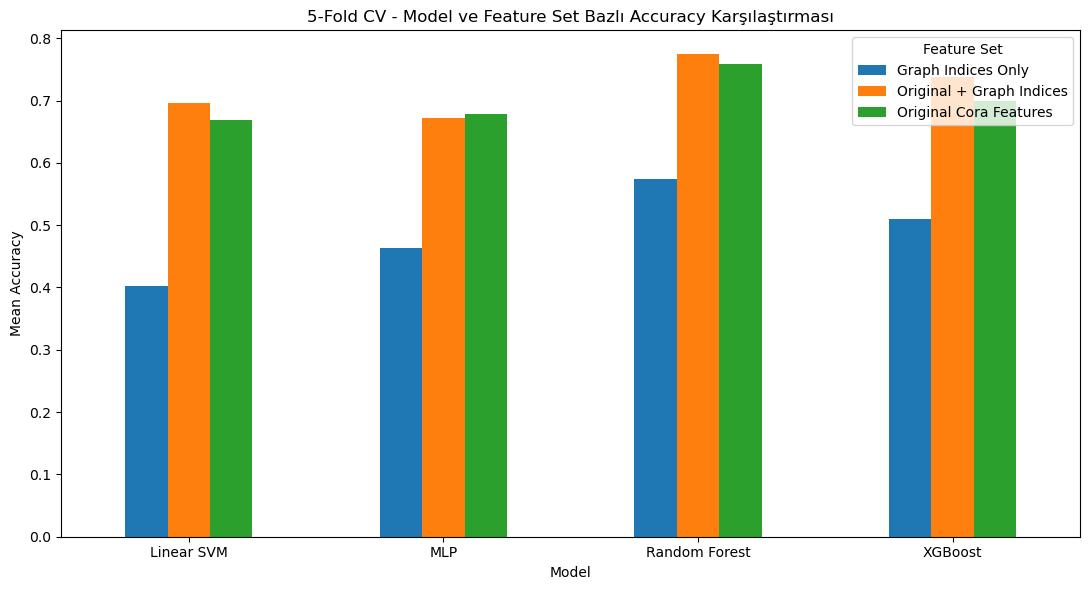

Kaydedildi: results/cv_accuracy_comparison.png


<Figure size 1100x600 with 0 Axes>

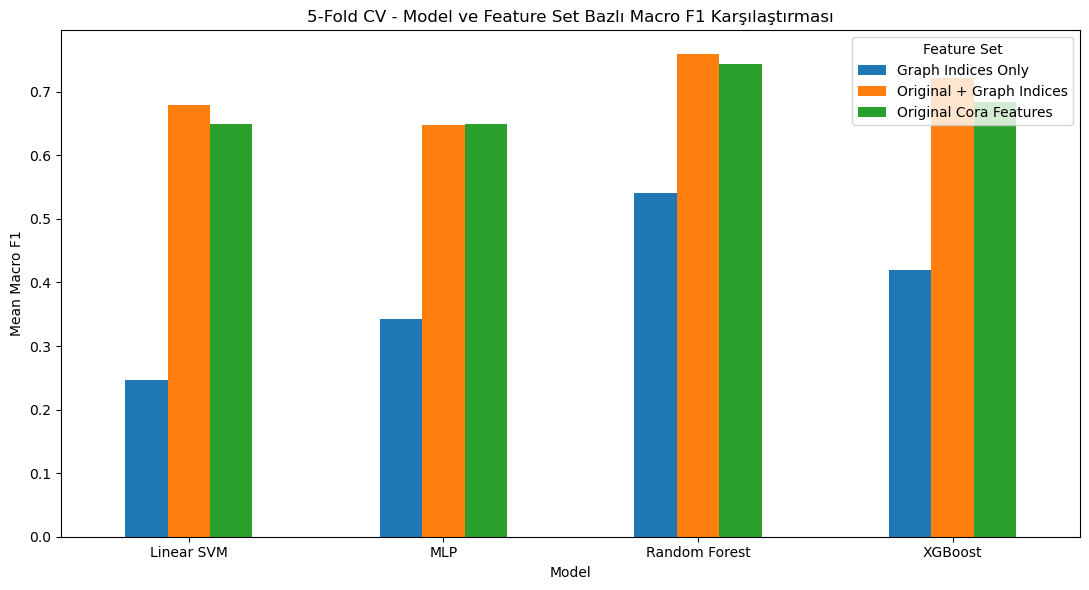

Kaydedildi: results/cv_macro_f1_comparison.png


<Figure size 1100x600 with 0 Axes>

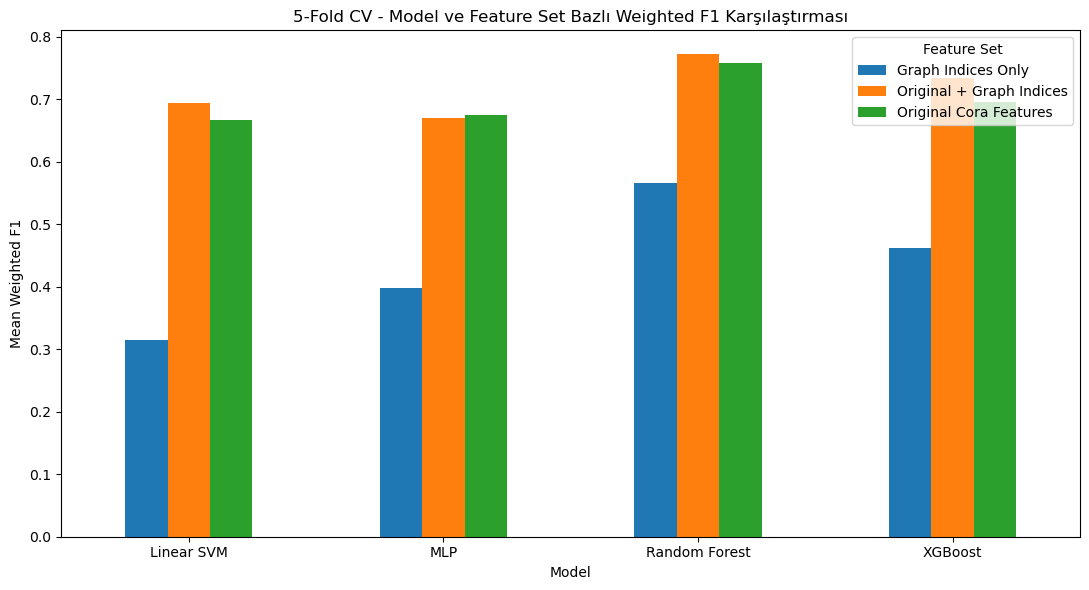

Kaydedildi: results/cv_weighted_f1_comparison.png


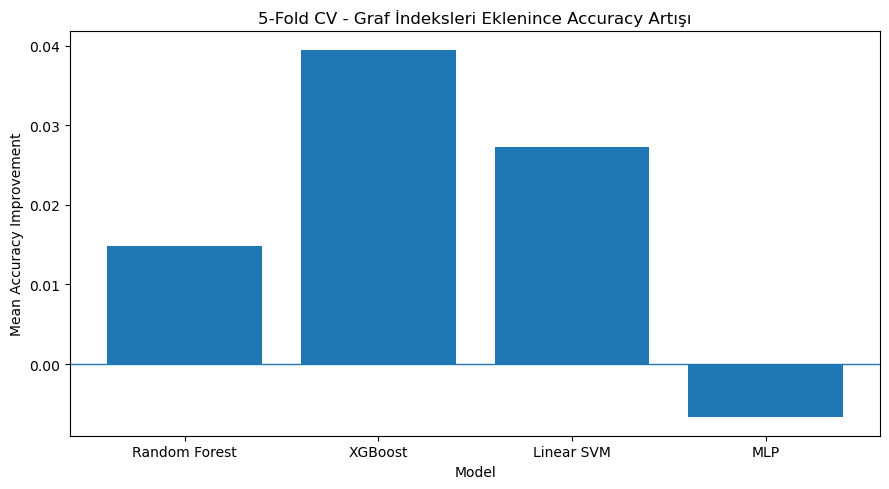

Kaydedildi: results/cv_accuracy_improvement.png


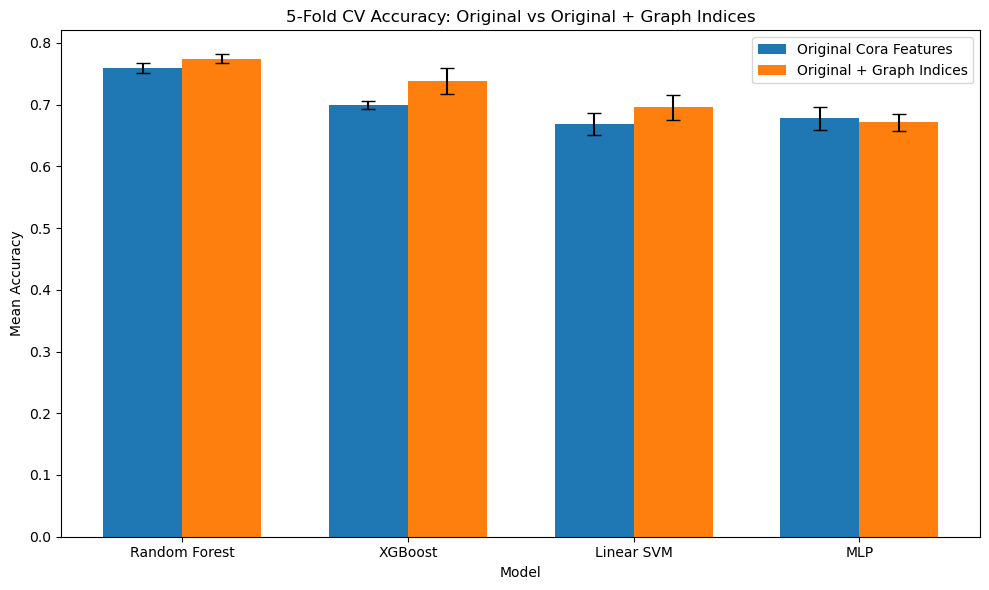

Kaydedildi: results/cv_accuracy_errorbar.png

Tez İçin 5-Fold CV Özet Tablosu


,Model,Feature_Set,Accuracy,Macro_F1,Weighted_F1
0,Random Forest,Original Cora Features,0.7592 ± 0.0079,0.7443 ± 0.0078,0.7577 ± 0.0078
1,Random Forest,Graph Indices Only,0.5742 ± 0.0039,0.5408 ± 0.008,0.5655 ± 0.0054
2,Random Forest,Original + Graph Indices,0.774 ± 0.0073,0.7587 ± 0.0071,0.7716 ± 0.0073
3,XGBoost,Original Cora Features,0.6987 ± 0.0064,0.6839 ± 0.0151,0.6961 ± 0.0075
4,XGBoost,Graph Indices Only,0.51 ± 0.0166,0.4201 ± 0.023,0.4615 ± 0.0182
5,XGBoost,Original + Graph Indices,0.7382 ± 0.0208,0.7221 ± 0.0221,0.7338 ± 0.0211
6,Linear SVM,Original Cora Features,0.6684 ± 0.0183,0.6496 ± 0.0153,0.6673 ± 0.0181
7,Linear SVM,Graph Indices Only,0.4018 ± 0.008,0.2459 ± 0.0121,0.3144 ± 0.0102
8,Linear SVM,Original + Graph Indices,0.6957 ± 0.02,0.6784 ± 0.0181,0.6945 ± 0.0207
9,MLP,Original Cora Features,0.678 ± 0.0185,0.6485 ± 0.0193,0.6753 ± 0.0185


Kaydedildi: results/cv_5fold_summary_for_thesis.csv

Results klasöründeki CV dosyaları:
- cv_5fold_summary_for_thesis.csv
- cv_5fold_accuracy_improvement.csv
- cv_weighted_f1_comparison.png
- cv_5fold_results.csv
- cv_accuracy_comparison.png
- cv_macro_f1_comparison.png
- cv_accuracy_errorbar.png
- cv_accuracy_improvement.png


In [16]:
# ==================================================
# ADIM 17: 5-Fold CV Sonuçlarını Grafikleştirme ve Kaydetme
# ==================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# 1. Sonuç klasörü
# --------------------------------------------------

results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# --------------------------------------------------
# 2. CV sonuç tablolarını kontrol edelim
# --------------------------------------------------

print("="*80)
print("5-Fold CV Sonuç Tablosu")
print("="*80)
display(cv_results_df)

print("\n" + "="*80)
print("5-Fold CV Accuracy Improvement Tablosu")
print("="*80)
display(cv_improvement_df)

# --------------------------------------------------
# 3. Accuracy karşılaştırma grafiği
# --------------------------------------------------

pivot_cv_accuracy = cv_results_df.pivot(
    index="Model",
    columns="Feature_Set",
    values="Accuracy_Mean"
)

plt.figure(figsize=(11, 6))
pivot_cv_accuracy.plot(kind="bar", figsize=(11, 6))

plt.title("5-Fold CV - Model ve Feature Set Bazlı Accuracy Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Mean Accuracy")
plt.xticks(rotation=0)
plt.legend(title="Feature Set")
plt.tight_layout()

cv_accuracy_path = os.path.join(results_dir, "cv_accuracy_comparison.png")
plt.savefig(cv_accuracy_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", cv_accuracy_path)

# --------------------------------------------------
# 4. Macro F1 karşılaştırma grafiği
# --------------------------------------------------

pivot_cv_macro_f1 = cv_results_df.pivot(
    index="Model",
    columns="Feature_Set",
    values="Macro_F1_Mean"
)

plt.figure(figsize=(11, 6))
pivot_cv_macro_f1.plot(kind="bar", figsize=(11, 6))

plt.title("5-Fold CV - Model ve Feature Set Bazlı Macro F1 Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Mean Macro F1")
plt.xticks(rotation=0)
plt.legend(title="Feature Set")
plt.tight_layout()

cv_macro_f1_path = os.path.join(results_dir, "cv_macro_f1_comparison.png")
plt.savefig(cv_macro_f1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", cv_macro_f1_path)

# --------------------------------------------------
# 5. Weighted F1 karşılaştırma grafiği
# --------------------------------------------------

pivot_cv_weighted_f1 = cv_results_df.pivot(
    index="Model",
    columns="Feature_Set",
    values="Weighted_F1_Mean"
)

plt.figure(figsize=(11, 6))
pivot_cv_weighted_f1.plot(kind="bar", figsize=(11, 6))

plt.title("5-Fold CV - Model ve Feature Set Bazlı Weighted F1 Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Mean Weighted F1")
plt.xticks(rotation=0)
plt.legend(title="Feature Set")
plt.tight_layout()

cv_weighted_f1_path = os.path.join(results_dir, "cv_weighted_f1_comparison.png")
plt.savefig(cv_weighted_f1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", cv_weighted_f1_path)

# --------------------------------------------------
# 6. Graf indeksleri eklenince Accuracy artışı grafiği
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    cv_improvement_df["Model"],
    cv_improvement_df["CV_Accuracy_Improvement"]
)

plt.axhline(0, linewidth=1)
plt.title("5-Fold CV - Graf İndeksleri Eklenince Accuracy Artışı")
plt.xlabel("Model")
plt.ylabel("Mean Accuracy Improvement")
plt.tight_layout()

cv_improvement_path = os.path.join(results_dir, "cv_accuracy_improvement.png")
plt.savefig(cv_improvement_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", cv_improvement_path)

# --------------------------------------------------
# 7. Error bar grafiği: Original vs Combined
# --------------------------------------------------
# Bu grafik ortalama accuracy ile standart sapmayı birlikte gösterir.
# Tez için oldukça kullanışlıdır.

selected_feature_sets = [
    "Original Cora Features",
    "Original + Graph Indices"
]

cv_errorbar_df = cv_results_df[
    cv_results_df["Feature_Set"].isin(selected_feature_sets)
].copy()

models = cv_errorbar_df["Model"].unique()
x = np.arange(len(models))
width = 0.35

original_means = []
original_stds = []
combined_means = []
combined_stds = []

for model in models:
    model_df = cv_errorbar_df[cv_errorbar_df["Model"] == model]
    
    original_row = model_df[
        model_df["Feature_Set"] == "Original Cora Features"
    ].iloc[0]
    
    combined_row = model_df[
        model_df["Feature_Set"] == "Original + Graph Indices"
    ].iloc[0]
    
    original_means.append(original_row["Accuracy_Mean"])
    original_stds.append(original_row["Accuracy_Std"])
    
    combined_means.append(combined_row["Accuracy_Mean"])
    combined_stds.append(combined_row["Accuracy_Std"])

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    original_means,
    width,
    yerr=original_stds,
    capsize=5,
    label="Original Cora Features"
)

plt.bar(
    x + width/2,
    combined_means,
    width,
    yerr=combined_stds,
    capsize=5,
    label="Original + Graph Indices"
)

plt.title("5-Fold CV Accuracy: Original vs Original + Graph Indices")
plt.xlabel("Model")
plt.ylabel("Mean Accuracy")
plt.xticks(x, models, rotation=0)
plt.legend()
plt.tight_layout()

cv_errorbar_path = os.path.join(results_dir, "cv_accuracy_errorbar.png")
plt.savefig(cv_errorbar_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", cv_errorbar_path)

# --------------------------------------------------
# 8. Tez için daha okunabilir özet tablo oluşturma
# --------------------------------------------------

cv_summary_for_thesis = cv_results_df.copy()

cv_summary_for_thesis["Accuracy"] = (
    cv_summary_for_thesis["Accuracy_Mean"].astype(str)
    + " ± "
    + cv_summary_for_thesis["Accuracy_Std"].astype(str)
)

cv_summary_for_thesis["Macro_F1"] = (
    cv_summary_for_thesis["Macro_F1_Mean"].astype(str)
    + " ± "
    + cv_summary_for_thesis["Macro_F1_Std"].astype(str)
)

cv_summary_for_thesis["Weighted_F1"] = (
    cv_summary_for_thesis["Weighted_F1_Mean"].astype(str)
    + " ± "
    + cv_summary_for_thesis["Weighted_F1_Std"].astype(str)
)

cv_summary_for_thesis = cv_summary_for_thesis[
    [
        "Model",
        "Feature_Set",
        "Accuracy",
        "Macro_F1",
        "Weighted_F1"
    ]
]

print("\n" + "="*80)
print("Tez İçin 5-Fold CV Özet Tablosu")
print("="*80)

display(cv_summary_for_thesis)

cv_summary_path = os.path.join(results_dir, "cv_5fold_summary_for_thesis.csv")
cv_summary_for_thesis.to_csv(
    cv_summary_path,
    index=False,
    encoding="utf-8-sig"
)

print("Kaydedildi:", cv_summary_path)

# --------------------------------------------------
# 9. Kayıt kontrolü
# --------------------------------------------------

print("\nResults klasöründeki CV dosyaları:")
for file_name in os.listdir(results_dir):
    if file_name.startswith("cv_"):
        print("-", file_name)

In [17]:
# ============================================================
# ADIM 18: GCN Modeli ile GNN Karşılaştırması
# ============================================================
# Bu hücre, klasik ML modellerinden sonra GCN tabanlı bir karşılaştırma yapmak için eklenmiştir.
# PyTorch Geometric kullanılmaz; saf PyTorch sparse matris çarpımı ile çalışır.
#
# Deneyler:
# 1) GCN / Original Cora Features
# 2) GCN / Original + Graph Indices

print("\n" + "="*70, flush=True)
print("ADIM 18: GCN MODELİ İLE GNN KARŞILAŞTIRMASI", flush=True)
print("="*70, flush=True)

import os
import time
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F


# ------------------------------------------------------------
# 1. Rastgelelik kontrolü ve cihaz ayarı
# ------------------------------------------------------------

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Mac / CPU üzerinde fazla thread bazen yavaşlatabiliyor.
torch.set_num_threads(1)

device = torch.device("cpu")

print("Kullanılan cihaz:", device, flush=True)


# ------------------------------------------------------------
# 2. GCN için güvenli edge_index oluşturma
# ------------------------------------------------------------
# Cora paper_id değerleri 0,1,2,... şeklinde değildir.
# Bu yüzden paper_id değerlerini 0...2707 aralığına eşliyoruz.

node_ids_str = [str(node_id) for node_id in node_ids]

node_mapping = {
    node_id: idx for idx, node_id in enumerate(node_ids_str)
}

edges_mapped = []

for u, v in G.edges():
    u = str(u)
    v = str(v)

    if u in node_mapping and v in node_mapping:
        u_idx = node_mapping[u]
        v_idx = node_mapping[v]

        # GCN için grafı çift yönlü kullanıyoruz.
        edges_mapped.append([u_idx, v_idx])
        edges_mapped.append([v_idx, u_idx])

num_nodes = len(node_ids_str)

edge_index = torch.tensor(edges_mapped, dtype=torch.long).t().contiguous()

print("Düğüm sayısı:", num_nodes, flush=True)
print("edge_index min:", int(edge_index.min()), flush=True)
print("edge_index max:", int(edge_index.max()), flush=True)

assert edge_index.min() >= 0, "edge_index içinde negatif değer var."
assert edge_index.max() < num_nodes, "edge_index içinde düğüm sayısından büyük indeks var."


# ------------------------------------------------------------
# 3. Sparse normalize adjacency matrisi oluşturma
# ------------------------------------------------------------
# A_hat = D^(-1/2) (A + I) D^(-1/2)

def build_sparse_normalized_adjacency(edge_index, num_nodes):
    """
    GCN için normalize edilmiş sparse adjacency matrisi oluşturur.
    """

    # Self-loop ekle
    self_loops = torch.arange(num_nodes, dtype=torch.long)
    self_loops = self_loops.unsqueeze(0).repeat(2, 1)

    edge_index_with_loops = torch.cat([edge_index, self_loops], dim=1)

    row = edge_index_with_loops[0]
    col = edge_index_with_loops[1]

    values = torch.ones(row.size(0), dtype=torch.float32)

    # Derece hesabı
    degree = torch.zeros(num_nodes, dtype=torch.float32)
    degree.scatter_add_(0, row, values)

    degree_inv_sqrt = torch.pow(degree, -0.5)
    degree_inv_sqrt[torch.isinf(degree_inv_sqrt)] = 0.0

    norm_values = degree_inv_sqrt[row] * values * degree_inv_sqrt[col]

    adj_norm = torch.sparse_coo_tensor(
        indices=edge_index_with_loops,
        values=norm_values,
        size=(num_nodes, num_nodes)
    )

    return adj_norm.coalesce()


adj_norm = build_sparse_normalized_adjacency(edge_index, num_nodes).to(device)

print("Sparse adjacency non-zero sayısı:", adj_norm._nnz(), flush=True)


# ------------------------------------------------------------
# 4. GCN için feature ve label hazırlama
# ------------------------------------------------------------
# X_original_only, X_graph_only ve X_combined daha önceki hücrelerde oluşturulmuş olmalı.
# y string sınıf etiketleri içeriyorsa LabelEncoder ile sayısallaştırılır.

def prepare_gcn_features(X):
    """
    GCN için feature matrisini ölçekler ve torch tensor formatına çevirir.
    """

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

    return X_tensor


x_gcn_original = prepare_gcn_features(X_original_only)
x_gcn_combined = prepare_gcn_features(X_combined)

# String sınıf etiketlerini sayısal forma çeviriyoruz.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

y_tensor = torch.tensor(y_encoded, dtype=torch.long).to(device)

print("x_gcn_original boyutu:", x_gcn_original.shape, flush=True)
print("x_gcn_combined boyutu:", x_gcn_combined.shape, flush=True)
print("y_tensor boyutu:", y_tensor.shape, flush=True)
print("Sınıf sayısı:", len(label_encoder.classes_), flush=True)
print("Sınıflar:", list(label_encoder.classes_), flush=True)


# ------------------------------------------------------------
# 5. Train / Validation / Test indeksleri
# ------------------------------------------------------------

all_indices = np.arange(num_nodes)

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_encoded[temp_idx]
)

train_idx = torch.tensor(train_idx, dtype=torch.long).to(device)
val_idx = torch.tensor(val_idx, dtype=torch.long).to(device)
test_idx = torch.tensor(test_idx, dtype=torch.long).to(device)

print("Train düğüm sayısı:", train_idx.shape[0], flush=True)
print("Validation düğüm sayısı:", val_idx.shape[0], flush=True)
print("Test düğüm sayısı:", test_idx.shape[0], flush=True)


# ------------------------------------------------------------
# 6. Basit GCN modeli
# ------------------------------------------------------------

class SimpleGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super(SimpleGCN, self).__init__()

        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x, adj_norm):
        # 1. GCN katmanı
        x = torch.sparse.mm(adj_norm, x)
        x = self.linear1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # 2. GCN katmanı
        x = torch.sparse.mm(adj_norm, x)
        x = self.linear2(x)

        return x


# ------------------------------------------------------------
# 7. Eğitim ve değerlendirme fonksiyonu
# ------------------------------------------------------------

def train_evaluate_gcn(
    X_tensor,
    experiment_name,
    hidden_channels=32,
    epochs=80,
    patience=15,
    lr=0.01,
    weight_decay=5e-4
):
    """
    Verilen X_tensor için GCN modelini eğitir ve test sonuçlarını döndürür.
    """

    print("\n" + "="*70, flush=True)
    print(experiment_name, flush=True)
    print("="*70, flush=True)

    input_dim = X_tensor.shape[1]
    output_dim = len(np.unique(y_encoded))

    model = SimpleGCN(
        input_dim=input_dim,
        hidden_dim=hidden_channels,
        output_dim=output_dim,
        dropout=0.5
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_state_dict = None
    patience_counter = 0

    start_time = time.time()

    for epoch in range(1, epochs + 1):

        # --------------------
        # Eğitim
        # --------------------
        model.train()
        optimizer.zero_grad()

        out = model(X_tensor, adj_norm)

        train_loss = criterion(out[train_idx], y_tensor[train_idx])

        train_loss.backward()
        optimizer.step()

        # --------------------
        # Validation
        # --------------------
        model.eval()

        with torch.no_grad():
            out_eval = model(X_tensor, adj_norm)

            val_loss = criterion(out_eval[val_idx], y_tensor[val_idx])

            train_pred = out_eval[train_idx].argmax(dim=1)
            val_pred = out_eval[val_idx].argmax(dim=1)

            train_acc = accuracy_score(
                y_tensor[train_idx].cpu().numpy(),
                train_pred.cpu().numpy()
            )

            val_acc = accuracy_score(
                y_tensor[val_idx].cpu().numpy(),
                val_pred.cpu().numpy()
            )

        # Erken durdurma
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_state_dict = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        # Hücre donmuş gibi görünmesin diye sık çıktı veriyoruz.
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Val Acc: {val_acc:.4f}",
                flush=True
            )

        if patience_counter >= patience:
            print(f"Erken durdurma: Epoch {epoch}", flush=True)
            break

    elapsed_time = time.time() - start_time

    # En iyi modeli geri yükle
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    # --------------------
    # Test değerlendirmesi
    # --------------------
    model.eval()

    with torch.no_grad():
        final_out = model(X_tensor, adj_norm)
        test_pred = final_out[test_idx].argmax(dim=1)

        y_true = y_tensor[test_idx].cpu().numpy()
        y_pred = test_pred.cpu().numpy()

        test_accuracy = accuracy_score(y_true, y_pred)
        test_macro_f1 = f1_score(y_true, y_pred, average="macro")
        test_weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print("\nTest Sonuçları:", flush=True)
    print(f"Accuracy   : {test_accuracy:.4f}", flush=True)
    print(f"Macro F1   : {test_macro_f1:.4f}", flush=True)
    print(f"Weighted F1: {test_weighted_f1:.4f}", flush=True)
    print(f"Süre       : {elapsed_time:.2f} sn", flush=True)

    result = {
        "Experiment": experiment_name,
        "Model": "GCN",
        "Accuracy": test_accuracy,
        "Macro_F1": test_macro_f1,
        "Weighted_F1": test_weighted_f1,
        "Time_Seconds": elapsed_time,
        "Input_Feature_Count": input_dim
    }

    return result


# ------------------------------------------------------------
# 8. GCN deneyleri
# ------------------------------------------------------------

gcn_results = []

gcn_result_original = train_evaluate_gcn(
    X_tensor=x_gcn_original,
    experiment_name="GCN / Original Cora Features",
    hidden_channels=32,
    epochs=80,
    patience=15
)

gcn_results.append(gcn_result_original)


gcn_result_combined = train_evaluate_gcn(
    X_tensor=x_gcn_combined,
    experiment_name="GCN / Original + Graph Indices",
    hidden_channels=32,
    epochs=80,
    patience=15
)

gcn_results.append(gcn_result_combined)


# ------------------------------------------------------------
# 9. Sonuçların kaydedilmesi
# ------------------------------------------------------------

gcn_results_df = pd.DataFrame(gcn_results)

print("\nGCN Sonuçları:", flush=True)
display(gcn_results_df)

os.makedirs("results", exist_ok=True)

gcn_results_df.to_csv(
    "results/gcn_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("GCN sonuçları results/gcn_results.csv dosyasına kaydedildi.", flush=True)


# Daha önceki genel sonuç tablosu varsa GCN sonuçlarını ona ekle
if "results_df" in globals():
    try:
        all_results_with_gcn = pd.concat(
            [results_df, gcn_results_df],
            ignore_index=True
        )

        all_results_with_gcn.to_csv(
            "results/all_results_with_gcn.csv",
            index=False,
            encoding="utf-8-sig"
        )

        print("Tüm sonuçlar results/all_results_with_gcn.csv dosyasına kaydedildi.", flush=True)
        display(all_results_with_gcn)

    except Exception as e:
        print("Genel sonuç tablosu ile birleştirme yapılamadı:", e, flush=True)

else:
    print("results_df bulunamadı. Sadece GCN sonuçları kaydedildi.", flush=True)


print("\nADIM 18 tamamlandı.", flush=True)


ADIM 18: GCN MODELİ İLE GNN KARŞILAŞTIRMASI
Kullanılan cihaz: cpu
Düğüm sayısı: 2708
edge_index min: 0
edge_index max: 2707
Sparse adjacency non-zero sayısı: 13264
x_gcn_original boyutu: torch.Size([2708, 1433])
x_gcn_combined boyutu: torch.Size([2708, 1440])
y_tensor boyutu: torch.Size([2708])
Sınıf sayısı: 7
Sınıflar: ['Case_Based', 'Genetic_Algorithms', 'Neural_Networks', 'Probabilistic_Methods', 'Reinforcement_Learning', 'Rule_Learning', 'Theory']
Train düğüm sayısı: 1624
Validation düğüm sayısı: 542
Test düğüm sayısı: 542

GCN / Original Cora Features
Epoch 001 | Train Loss: 1.9610 | Val Loss: 1.5219 | Train Acc: 0.8294 | Val Acc: 0.7970
Epoch 005 | Train Loss: 0.5962 | Val Loss: 0.5664 | Train Acc: 0.9033 | Val Acc: 0.8524
Epoch 010 | Train Loss: 0.2495 | Val Loss: 0.4756 | Train Acc: 0.9323 | Val Acc: 0.8819
Epoch 015 | Train Loss: 0.1750 | Val Loss: 0.5480 | Train Acc: 0.9514 | Val Acc: 0.8838
Epoch 020 | Train Loss: 0.1312 | Val Loss: 0.6101 | Train Acc: 0.9643 | Val Acc: 0.8

,Experiment,Model,Accuracy,Macro_F1,Weighted_F1,Time_Seconds,Input_Feature_Count
0,GCN / Original Cora Features,GCN,0.881919,0.877792,0.881533,2.145951,1433
1,GCN / Original + Graph Indices,GCN,0.863469,0.859677,0.863276,2.113164,1440


GCN sonuçları results/gcn_results.csv dosyasına kaydedildi.
results_df bulunamadı. Sadece GCN sonuçları kaydedildi.

ADIM 18 tamamlandı.
